# Customer Reactivation Prediction Model — Annotated Notebook

**PURPOSE:** This notebook is a commented copy of the original analysis. Each section has plain-English explanations aimed at a non-technical reader, plus notes on potential issues, alternative approaches, and a concrete recommendation on what to do.

**PROJECT GOAL:** Predict which inactive (churned) customers are most likely to come back if we run a marketing campaign, so the company can focus budget on the best targets.


## IMPORTS & SETUP

**WHAT THIS DOES:**
  Loads all the software libraries we need. Think of these like toolboxes:
  - pandas / numpy: for working with data tables and numbers
  - matplotlib / seaborn: for making charts
  - sklearn: the main machine learning toolkit (models, preprocessing, evaluation)
  - lightgbm / xgboost: advanced ML models (boosted decision trees)
  - shap: explains WHY the model made each prediction

**POTENTIAL ISSUES:**
  - warnings.filterwarnings('ignore') hides ALL warnings. This is convenient for
    a clean notebook, but dangerous in production — warnings often flag real problems
    (e.g., convergence issues, deprecated features). Better to filter specific warnings.

**ALTERNATIVES:**
  - Could use CatBoost instead of (or in addition to) LightGBM/XGBoost — it handles
    categorical features natively without encoding.
  - Could use LIME instead of SHAP for explanations (simpler but less theoretically
    grounded).

**RECOMMENDATION:**
  Keep the current setup but make two changes:
  (1) Add CatBoost to the model candidates — it often outperforms on tabular data
      with categoricals and would let us skip the encoding step entirely for that model.
  (2) Replace warnings.filterwarnings('ignore') with targeted suppression:
      warnings.filterwarnings('ignore', category=ConvergenceWarning)
      This way you still see unexpected warnings (e.g., deprecation, data issues)
      while hiding the noisy ones from sklearn.
  Keep SHAP over LIME — SHAP is the industry standard for tree-based models and
  TreeExplainer is both fast and exact. LIME would be a downgrade here.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder, StandardScaler, RobustScaler)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from scipy.stats import ks_2samp

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})


SHAP not installed. Run: pip install shap


## DATA LOADING

**WHAT THIS DOES:**
  Loads two CSV files from Google Drive:
  1. TOOL_CLIENT.csv — one row per customer (demographics, risk category, etc.)
  2. TOOL_SALES.csv — one row per transaction (what was bought, when, how much)

  CLIENT_ID is forced to be text (not a number) so IDs like "007" don't lose
  leading zeros.

**POTENTIAL ISSUES:**
  - The Google Drive mount cell (cell 1) is Colab-specific. If running locally,
    you'd need to change the file paths.
  - low_memory=False on the sales read tells pandas to scan the whole file first
    to determine column types — safer but uses more memory.

**ALTERNATIVES:**
  - For very large datasets, consider using Dask or Polars instead of pandas.
  - Could load from a database (SQL) instead of CSVs for a production pipeline.
  - Parquet format would be faster and smaller than CSV.

**RECOMMENDATION:**
  The current approach is fine for this project size. The only change I'd make:
  save a copy of the cleaned data as Parquet after cleaning (Section 3-5) so that
  re-runs don't have to repeat the slow CSV parsing + cleaning every time.
  Something like: sales.to_parquet('sales_clean.parquet') at the end of cleaning.
  For the consultancy deliverable, CSVs are the right input format since that's
  what the client provided.

from google.colab import drive
drive.mount('datasets',force_remount=True)


In [2]:
clients = pd.read_csv(
    './TOOL_CLIENT.csv',
    dtype={'CLIENT_ID': str}
)

sales = pd.read_csv(
    './TOOL_SALES.csv',
    dtype={'CLIENT_ID': str, 'ITEM_ID': str, 'CANCELLED': str},
    low_memory=False
)

initial_number_of_sales = len(sales)
initial_number_of_clients = len(clients)

print(f'Sales  : {sales.shape[0]:,} rows × {sales.shape[1]} cols')
print(f'Clients: {clients.shape[0]:,} rows × {clients.shape[1]} cols')


Sales  : 2,050,449 rows × 10 cols
Clients: 93,257 rows × 8 cols


## DATA CLEANING & TYPE CASTING

**WHAT THIS DOES:**
  Converts columns to their correct data types:
  - Dates become proper date objects (so we can do date math)
  - Text fields become "string" type
  - CANCELLED flag: converts "X" → 1, everything else → 0
  - Missing regions filled with "unknown"

**WHY IT MATTERS:**
  If dates are stored as text, you can't sort by date or calculate "months since
  last purchase." If categories are stored as numbers, the model might think
  "region 3" is somehow bigger than "region 1."

**POTENTIAL ISSUES:**
  - REGION is cast to string twice (line duplication, harmless but messy).
  - Filling missing REGION with "unknown" is fine, but the model will treat it as
    its own category. If many clients have unknown region, this could dilute signal.

**ALTERNATIVES:**
  - Could drop rows with missing REGION instead of filling (if few).
  - Could impute REGION based on other features (e.g., trade sector patterns).

**RECOMMENDATION:**
  Keep fillna("unknown") — dropping rows would lose data, and imputing region from
  other features adds complexity for little gain. But remove the duplicate
  .astype("string") line — it's just clutter. Also, I'd add an assertion or
  print statement after cleaning to confirm no unexpected NaN values remain:
      print(clients.isnull().sum())
  This is a quick sanity check that costs nothing and catches silent issues.


In [3]:
clients["CLIENT_CREATE DATE"] = pd.to_datetime(clients["CLIENT_CREATE DATE"])
clients["REGION"]             = clients["REGION"].astype("string")
clients["REGION"]             = clients["REGION"].fillna("unknown")
clients["REGION"]             = clients["REGION"].astype("string")
clients["ECO_POT_CLASS"]      = clients["ECO_POT_CLASS"].astype("string")
clients["RISK_CAT"]           = clients["RISK_CAT"].astype("string")
sales["UNIT"]                 = sales["UNIT"].astype("string")
sales["FAMILY_CODE"]          = sales["FAMILY_CODE"].astype("string")
sales["YYYYMM"]               = pd.to_datetime(sales["YYYYMM"], format="%Y%m")
sales["SALES_CHANNEL"]        = sales["SALES_CHANNEL"].astype("string")
sales['CANCELLED']            = (sales['CANCELLED'] == 'X').astype(int)


## INSPECTING TRANSACTIONS — NEGATIVE & ZERO VALUES

**WHAT THIS DOES:**
  Separates transactions into three buckets:
  - Positive NET values (normal purchases) → kept in the NET column
  - Negative NET values (returns/refunds) → saved in a new NNET column
  - Zero NET values (unclear — maybe free samples, corrections) → saved in 0NET column

  After splitting, the original NET column only contains positive values (NaN otherwise).
  This lets us build separate features later (e.g., "how many returns did this client make?").

**POTENTIAL ISSUES:**
  - Overwriting NET with NaN for non-positive values means we LOSE the original NET column.
    If we need it later, we'd have to re-derive it. Safer to keep the original and create
    a new column like "NET_positive".
  - The .where() logic is a bit convoluted. A simpler approach would be:
      sales['NNET'] = sales['NET'].where(sales['NET'] < 0)
      sales['0NET'] = sales['NET'].where(sales['NET'] == 0)
      sales['NET']  = sales['NET'].where(sales['NET'] > 0)

**ALTERNATIVES:**
  - Could create a single "transaction_type" column: 'purchase', 'return', 'zero'
  - Could flag returns as a boolean column instead of keeping the amount separately.
  - Returns might be informative: high return rate = less loyal customer (useful feature).

**RECOMMENDATION:**
  First: preserve the original NET column — rename it NET_original or copy it before
  modifying. You never want to destroy raw data in-place.
  Second: simplify to a "transaction_type" categorical column plus keep the original
  NET intact. Then in the feature engineering step, build return-related features
  (return_count, return_rate, net_after_returns) directly from the original data.
  The current approach works but is fragile — if any downstream code expects NET to
  have all values (not just positives), it will silently get wrong results.


In [4]:
sales.loc[sales['NET'] < 0, 'NNET'] = sales['NET']
sales.loc[sales['NET'] == 0, '0NET'] = sales['NET']
sales['NNET'] = sales['NNET'].where(sales['NNET'] < 0, np.nan)
sales['0NET'] = sales['0NET'].where(sales['0NET'] == 0, np.nan)
sales['NET'] = sales['NET'].where(sales['NET'] > 0, np.nan)

transactions_with_negative_values = len(sales[sales['NNET'] < 0])
transactions_with_0_value = len(sales[sales['0NET'] == 0])


## REMOVING NOISE — STANDALONE & SINGLE-DAY PURCHASERS

**WHAT THIS DOES:**
  Removes two types of "noise" clients who won't be useful for prediction:

  A) "Standalone" clients: bought exactly ONCE ever and never came back.
     → These give us no purchase pattern to learn from.

  B) "Single-day" clients: bought multiple items but ALL on the same day, then
     disappeared. → Likely a one-off bulk order, not a real ongoing relationship.

**WHY IT MATTERS:**
  If we keep these clients, they'd all be labeled "churned" and they'd add noise
  to the model. They were never really active customers — they were one-time buyers.

**POTENTIAL ISSUES:**
  - We're removing these from BOTH the sales AND clients tables. This is correct
    for modeling, but we should document how many we removed (the notebook does this).
  - The groupby logic uses YYYYMM (year-month), not exact dates. So a client who
    bought on Jan 1 and Jan 31 would show as buying on 2 different "days" even though
    both are in the same month. This is actually grouping by MONTH, not by day.
    ⚠️  The variable name "n_days_purchase" is misleading — it's really "n_months."

**ALTERNATIVES:**
  - Could keep these clients but in a separate "one-timers" segment.
  - Could set a minimum threshold (e.g., at least 3 transactions across 2+ months)
    to be included in the modeling population.
  - If exact dates were available, grouping by actual date would be more precise.

**RECOMMENDATION:**
  The logic is sound — removing one-timers is standard practice in churn modeling.
  Two improvements:
  (1) Rename variables to reflect they're month-based, not day-based. Misleading
      names cause confusion when someone else reads the code later.
  (2) Consider a slightly stricter filter: require at least 2 DISTINCT months of
      purchase activity to be included. This catches edge cases like a client who
      bought 5 items in January 2017 and nothing else — technically not "standalone"
      but still a one-time buyer. The current code already does part B for this,
      but making it explicit as a single rule would be cleaner.
  Don't keep one-timers as a separate segment — they can't be modeled and would
  just add noise to the campaign list.

Part A: Remove clients with exactly one transaction ever


In [5]:
df_unique = sales[~sales["CLIENT_ID"].duplicated(keep=False)]
standalone_transactions = len(df_unique)
clients_who_made_1_transaction = set(df_unique["CLIENT_ID"])
sales = sales[~sales['CLIENT_ID'].isin(clients_who_made_1_transaction)]
clients = clients[~clients['CLIENT_ID'].isin(clients_who_made_1_transaction)]
print(len(sales))
print(len(clients))

# Part B: Remove clients who bought on only one day (month) but had multiple items
daily_counts = (
    sales.groupby(['CLIENT_ID', 'YYYYMM'])
    .size()
    .reset_index(name='n_days_purchase')
)

days_per_client = (
    sales.groupby('CLIENT_ID')['YYYYMM']
    .nunique()
    .reset_index(name='n_days')
)

multi_same_day = (
    daily_counts.groupby('CLIENT_ID')['n_days_purchase']
    .max()
    .reset_index(name='max_same_day_purchases')
)

single_day_purchase_clients = (
    days_per_client.merge(multi_same_day, on='CLIENT_ID')
)

single_day_purchase_clients = single_day_purchase_clients[
    (single_day_purchase_clients['n_days'] == 1) &
    (single_day_purchase_clients['max_same_day_purchases'] > 1)
]['CLIENT_ID']

multiple_1day_purchase_transactions = sales[sales['CLIENT_ID'].isin(single_day_purchase_clients)]
sales = sales[~sales['CLIENT_ID'].isin(single_day_purchase_clients)]
clients = clients[~clients['CLIENT_ID'].isin(single_day_purchase_clients)]


2037299
80107


## DATE EXTRACTION — YEAR & MONTH COLUMNS

**WHAT THIS DOES:**
  Extracts year and month from the YYYYMM date column into separate columns.
  This makes it easy to filter by year (e.g., "all 2019 transactions").

**POTENTIAL ISSUES:**
  ⚠️  BUG: str.zfill(0) does NOTHING. zfill pads a string to a minimum length,
  and 0 means "pad to at least 0 characters" — which is always already true.
  This was probably meant to be zfill(6) to ensure dates like "20171" become "020171",
  but since the dates were already parsed as datetime and then converted to string,
  the format is "2017-01-01 00:00:00", not "201701". The str[:4] for year and
  str[5:7] for month work because of the datetime string format, not YYYYMM format.

**ALTERNATIVES:**
  - Since YYYYMM was already converted to datetime, could use:
      sales['year'] = sales['YYYYMM'].dt.year
      sales['month'] = sales['YYYYMM'].dt.month
    This is cleaner and avoids string parsing entirely.

**RECOMMENDATION:**
  Use the .dt accessor — it's the correct, idiomatic pandas way to extract date parts:
      sales['year']  = sales['YYYYMM'].dt.year
      sales['month'] = sales['YYYYMM'].dt.month
  This is cleaner, faster, and doesn't depend on how Python formats datetime strings.
  The current string-slicing approach happens to work but is brittle — if pandas
  ever changes the default datetime string format, it would silently break.
  Remove the zfill(0) line entirely.


In [6]:
# Extract year and month directly from datetime column
sales['year']  = sales['YYYYMM'].dt.year
sales['month'] = sales['YYYYMM'].dt.month

## VISUALIZATION — TRANSACTION SUMMARY

**WHAT THIS DOES:**
  Creates a bar chart and summary tables showing how many transactions were:
  - Total initial count
  - Negative (returns)
  - Zero value
  - Standalone (one-time buyers)
  - Single-day purchasers

  This is a sanity check / documentation step — it shows stakeholders how much
  data was cleaned and why.

**POTENTIAL ISSUES:**
  - The percentage calculation in to_display1 divides by initial_number_of_SALES
    instead of initial_number_of_CLIENTS. This is likely a bug — you'd want
    "% of clients" not "% of transactions."

**ALTERNATIVES:**
  - Could use a waterfall chart (funnel) to show data flowing from raw → clean.
  - Could add a Sankey diagram for a more visual representation.

**RECOMMENDATION:**
  Fix the percentage bug (divide by clients, not sales). Beyond that, replace
  the plain bar chart with a waterfall/funnel chart — it's a much more intuitive
  way to show "we started with X, removed Y for reason A, Z for reason B, ended
  with W." For a consultancy deliverable, this visual storytelling matters.
  The summary DataFrames (to_display, to_display1, to_display2) could be merged
  into a single clean summary table — three separate DataFrames is confusing for
  stakeholders.


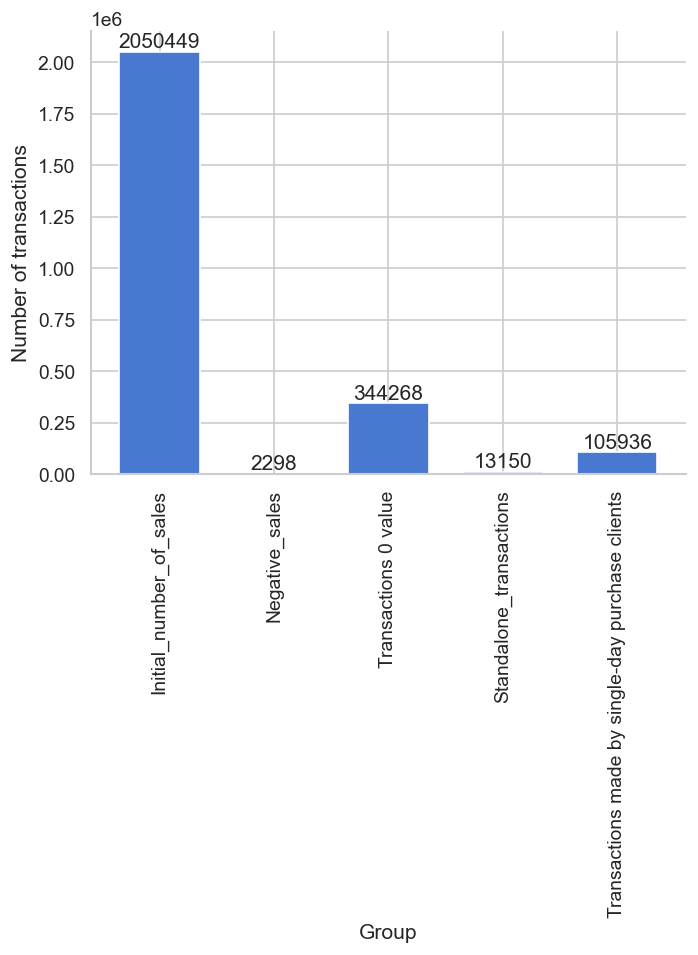

In [7]:
import matplotlib.pyplot as plt

visualize_transactions = pd.Series({
    "Initial_number_of_sales": initial_number_of_sales,
    "Negative_sales": transactions_with_negative_values,
    "Transactions 0 value": transactions_with_0_value,
    "Standalone_transactions": standalone_transactions,
    "Transactions made by single-day purchase clients": len(multiple_1day_purchase_transactions)
})

ax = visualize_transactions.plot(kind='bar', width=0.7)
for i, v in enumerate(visualize_transactions.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.xlabel('Group')
plt.ylabel('Number of transactions')
plt.show()

to_display = pd.DataFrame([{
    "Transactions with negative values:": transactions_with_negative_values,
    "Transactions with 0 value:": transactions_with_0_value,
    "Total N° transactions": initial_number_of_sales,
    "Percentage": (transactions_with_negative_values+transactions_with_0_value) / initial_number_of_sales * 100
}])
to_display1 = pd.DataFrame([{
    "N° of clints of \"standalone\" transactions:": len(clients_who_made_1_transaction),
    "Total N° of clients": initial_number_of_clients,
    "Percentage": len(clients_who_made_1_transaction) / initial_number_of_clients * 100,  # Fixed: now divides by client count
}])
to_display2 = pd.DataFrame([{
    "N° of single-day-purchase clients:": len(single_day_purchase_clients),
    "Total N° of clients": initial_number_of_clients,
    "Percentage": len(single_day_purchase_clients)/ initial_number_of_clients*100,
}])

# display(to_display)
# display(to_display1)
# display(to_display2)


## TIME WINDOW DEFINITION & CHURN LOGIC

**WHAT THIS DOES:**
  This is the MOST IMPORTANT design decision in the notebook.
  It splits the data into three time periods:

  |--- 2017-01 to 2019-06 ---|--- 2019-07 to 2021-06 ---|--- 2021-07 to 2021-12 ---|
  |    Observation window     |    Gap (2 yr inactivity) |    Target window (6 mo)  |
  |    (learn patterns)       |    (silence required)    |    (did they return?)    |

  - OBSERVATION (Jan 2017 – Jun 2019): We extract features from this period (spend, frequency, etc.)
  - GAP (Jul 2019 – Jun 2021): If a client did NOT buy in this 2-year window, we call them "churned"
  - TARGET (Jul 2021 – Dec 2021): If a churned client bought again → target = 1 (reactivated)

**WHY IT MATTERS:**
  The entire model depends on this split. If the windows are wrong, the predictions
  will be meaningless. For example, if a client's last purchase was December 2018,
  calling them "churned" after just 12 months might be too aggressive for a B2B
  company where purchases are infrequent.

**DESIGN NOTES:**
  - The 2-year gap largely covers the COVID period (Jul 2019 – Jun 2021),
    so pandemic effects fall within the inactivity window rather than the target.
  - The 6-month target (Jul–Dec 2021) captures post-pandemic recovery behavior,
    which is more representative of normal going-forward patterns.
  - The longer 2-year gap produces a more confident churn definition and a lower
    baseline reactivation rate (~13.5%) compared to a 1-year gap, since clients who
    were merely in a long purchase cycle are less likely to stay silent for 24 months.

In [8]:
# Define time window boundaries using year/month columns
# Observation: Jan 2017 – Jun 2019  |  Gap: Jul 2019 – Jun 2021  |  Target: Jul 2021 – Dec 2021
is_obs    = (sales['year'] < 2019) | ((sales['year'] == 2019) & (sales['month'] <= 6))
is_gap    = ((sales['year'] == 2019) & (sales['month'] >= 7)) | (sales['year'] == 2020) | ((sales['year'] == 2021) & (sales['month'] <= 6))
is_target = (sales['year'] == 2021) & (sales['month'] >= 7)

obs_sales    = sales[is_obs].copy()       # Jan 2017 – Jun 2019
gap_sales    = sales[is_gap].copy()       # Jul 2019 – Jun 2021
future_sales = sales[is_target].copy()    # Jul 2021 – Dec 2021

buyers_obs    = set(obs_sales['CLIENT_ID'].unique())
buyers_gap    = set(gap_sales['CLIENT_ID'].unique())
churned_ids   = buyers_obs - buyers_gap   # bought in observation, silent during 2-year gap

buyers_future = set(future_sales['CLIENT_ID'].unique())

clients_churn = clients[clients['CLIENT_ID'].isin(churned_ids)]
clients_churn = clients_churn.sort_values('CLIENT_ID', ascending=True)

target_series = pd.Series(
    {cid: int(cid in buyers_future) for cid in churned_ids},
    name='target'
).sort_index(ascending=True)

print(f'Observation buyers (2017-01 to 2019-06) : {len(buyers_obs):>6,}')
print(f'Clients who also bought in gap period   : {len(buyers_obs & buyers_gap):>6,}')
print(f'Churned (no purchase in 2-year gap)     : {len(churned_ids):>6,}')
print(f'  └─ Reactivated (target=1)             : {target_series.sum():>6,}  ({target_series.mean()*100:.1f}%)')
print(f'  └─ Remained dormant (target=0)        : {(1-target_series).sum():>6,}  ({(1-target_series.mean())*100:.1f}%)')

Observation buyers (2017-01 to 2019-06) : 51,752
Clients who also bought in gap period   : 36,703
Churned (no purchase in 2-year gap)     : 15,049
  └─ Reactivated (target=1)             :  2,038  (13.5%)
  └─ Remained dormant (target=0)        : 13,011  (86.5%)


## FEATURE ENGINEERING

**WHAT THIS DOES:**
  Builds the "profile" of each churned client based on their observation-window behavior (Jan 2017 – Jun 2019).
  These are the inputs the model will use to make predictions. Total: 28 numeric + 6 categorical = 34 features.

  **Core Transaction Features (from SALES):**
  - freq_n_transactions: how many times they bought
  - total_amount_spent: total money spent
  - average_amount_spent: average per transaction
  - max_amount_spent: biggest single purchase
  - std_amount_spent: how variable their spending was
  - n_distinct_channels: how many sales channels they used
  - main_channel: their most-used channel
  - n_product_families / n_product_groups: product breadth
  - n_canc: number of cancelled transactions
  - tool_ratio: fraction of spending on "tools"
  - n_neg_tranx / n_zero_tranx: return and zero-value transactions

  **Temporal Features (added V3):**
  - months_since_last_purchase: recency — months from last buy to end of obs window
  - tenure_months: months from account creation to end of obs window
  - avg_purchase_gap: average months between consecutive purchases
  - spending_trend: slope of monthly spend (positive = growing, negative = declining)
  - months_active: distinct months with at least one purchase

  **Product & Tool Features (added V3):**
  - n_distinct_items: number of unique products purchased (finer than family/group)
  - n_tool_transactions: count of tool purchases
  - is_tool_only: binary flag — does client only buy tools?
  - non_tool_spend: total EUR spent on non-tool products
  - main_family: most-purchased product family (categorical)

  **Behavioral Ratios (added V3):**
  - cancellation_rate: n_canc / freq_n_transactions (normalized cancellation signal)
  - return_rate: n_neg_tranx / freq_n_transactions (normalized return signal)
  - avg_basket_size: total_amount_spent / months_active (spend per active month)

  **Concentration Metrics (added V3):**
  - item_concentration: share of purchases going to single top item (0–1)
  - family_concentration: Herfindahl index across product families (1.0 = all one family)

  **Client-Level Features (from CLIENT):**
  - REGION, N_EMPLOYEES, ECONOMIC_POT, TRADE_SECTOR, RISK_CAT, ECO_POT_CLASS

In [9]:
churn_client_sales = obs_sales[obs_sales['CLIENT_ID'].isin(churned_ids)].copy()

tool_spend  = churn_client_sales[churn_client_sales['FLG_TOOL']==1].groupby('CLIENT_ID')['NET'].sum().rename('tool_spend')
total_spend = churn_client_sales.groupby('CLIENT_ID')['NET'].sum().rename('total_spend')
tool_ratio  = (tool_spend / total_spend).fillna(0).rename('tool_ratio')

model                = clients_churn[['CLIENT_ID']].copy()
final_clients_churn  = clients_churn[['CLIENT_ID']].copy()
total_amount_spent   = churn_client_sales.groupby('CLIENT_ID')['NET'].sum()
average_amount_spent = churn_client_sales.groupby('CLIENT_ID')['NET'].mean()
max_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].max()
std_amount_spent     = churn_client_sales.groupby('CLIENT_ID')['NET'].std().fillna(0)
freq_n_transactions  = churn_client_sales.groupby('CLIENT_ID')['NET'].count()
n_distinct_channels  = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].nunique()
main_channel         = churn_client_sales.groupby('CLIENT_ID')['SALES_CHANNEL'].agg(lambda x: x.mode().iloc[0])
n_product_families   = churn_client_sales.groupby('CLIENT_ID')['FAMILY_CODE'].nunique()
n_product_groups     = churn_client_sales.groupby('CLIENT_ID')['GROUP_CODE'].nunique()
n_canc               = churn_client_sales.groupby('CLIENT_ID')['CANCELLED'].sum()  # Fixed: .count() → .sum()
n_neg_tranx          = churn_client_sales.groupby('CLIENT_ID')['NNET'].apply(lambda x: x.notna().sum())  # count negative transactions explicitly
n_zero_tranx         = churn_client_sales.groupby('CLIENT_ID')['0NET'].apply(lambda x: x.notna().sum())  # count zero-value transactions explicitly
n_distinct_items     = churn_client_sales.groupby('CLIENT_ID')['ITEM_ID'].nunique()
n_tool_transactions  = churn_client_sales[churn_client_sales['FLG_TOOL']==1].groupby('CLIENT_ID').size()
main_family          = churn_client_sales.groupby('CLIENT_ID')['FAMILY_CODE'].agg(lambda x: x.mode().iloc[0])
months_active        = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].nunique()


# --- NEW FEATURES: Recency, Tenure, Purchase Gap, Spending Trend ---
obs_end = pd.Timestamp('2019-07-01')  # end of observation window

# RECENCY: months since last purchase (lower = more recent = more likely to reactivate)
last_purchase = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].max()
months_since_last_purchase = ((obs_end - last_purchase).dt.days / 30.44).round(1)

# TENURE: how long they've been a client (in months, from account creation to end of obs window)
tenure_months = clients_churn.set_index('CLIENT_ID')['CLIENT_CREATE DATE']
tenure_months = ((obs_end - tenure_months).dt.days / 30.44).round(1)

# INTER-PURCHASE GAP: average months between consecutive purchases
def avg_gap(dates):
    sorted_dates = dates.sort_values().unique()
    if len(sorted_dates) < 2:
        return 0.0
    gaps = pd.Series(sorted_dates).diff().dropna().dt.days / 30.44
    return gaps.mean()

avg_purchase_gap = churn_client_sales.groupby('CLIENT_ID')['YYYYMM'].apply(avg_gap)

# SPENDING TREND: slope of monthly spend over time (positive = growing, negative = declining)
def spend_slope(group):
    monthly = group.groupby('YYYYMM')['NET'].sum().dropna()
    if len(monthly) < 2:
        return 0.0
    x = np.arange(len(monthly))
    y = monthly.values.astype(float)
    slope = np.polyfit(x, y, 1)[0]
    return slope

spending_trend = churn_client_sales.groupby('CLIENT_ID').apply(spend_slope)

# --- DERIVED RATIOS ---
cancellation_rate  = (n_canc / freq_n_transactions).fillna(0)
return_rate         = (n_neg_tranx / freq_n_transactions).fillna(0)
is_tool_only        = (tool_ratio >= 1.0).astype(int)
non_tool_spend      = churn_client_sales[churn_client_sales['FLG_TOOL']!=1].groupby('CLIENT_ID')['NET'].sum().fillna(0)

# --- CONCENTRATION METRICS ---
avg_basket_size = (total_amount_spent / months_active).fillna(0).replace([np.inf, -np.inf], 0)

def top1_item_share(group):
    counts = group['ITEM_ID'].value_counts()
    return counts.iloc[0] / counts.sum() if len(counts) > 0 else 0.0

item_concentration = churn_client_sales.groupby('CLIENT_ID').apply(top1_item_share)

def family_hhi(group):
    counts = group['FAMILY_CODE'].value_counts()
    shares = counts / counts.sum()
    return (shares ** 2).sum()  # Herfindahl index: 1.0 = all in one family, ~0 = very spread

family_concentration = churn_client_sales.groupby('CLIENT_ID').apply(family_hhi)

# --- COVID SENSITIVITY FLAG (empirical) ---
# Compare each sector's monthly transaction volume pre-COVID vs during-COVID.
# Sectors with >30% drop are flagged as COVID-sensitive.
# Use full sales data (not just churned clients) for a robust sector-level signal.
_sales_with_sector = sales.merge(
    clients[['CLIENT_ID', 'TRADE SECTOR']], on='CLIENT_ID', how='left'
)
_pre_covid = _sales_with_sector[
    ((_sales_with_sector['year'] == 2019) & (_sales_with_sector['month'] >= 7)) |
    ((_sales_with_sector['year'] == 2020) & (_sales_with_sector['month'] <= 2))
]
_covid = _sales_with_sector[
    ((_sales_with_sector['year'] == 2020) & (_sales_with_sector['month'] >= 3)) |
    ((_sales_with_sector['year'] == 2021) & (_sales_with_sector['month'] <= 6))
]
_pre_monthly  = _pre_covid.groupby('TRADE SECTOR')['NET'].count() / 8
_covid_monthly = _covid.groupby('TRADE SECTOR')['NET'].count() / 16
_change_pct = ((_covid_monthly - _pre_monthly) / _pre_monthly.replace(0, np.nan) * 100)
_covid_sensitive_sectors = set(_change_pct[_change_pct < -30].index)

# Map to client level via their trade sector
_client_sectors = clients_churn.set_index('CLIENT_ID')['TRADE SECTOR']
covid_sensitive = _client_sectors.map(lambda s: int(s in _covid_sensitive_sectors))

print(f'COVID-sensitive sectors (>30% drop): {len(_covid_sensitive_sectors)}')
print(f'Clients flagged as COVID-sensitive: {covid_sensitive.sum()} / {len(covid_sensitive)}')

model['freq_n_transactions']    = model['CLIENT_ID'].map(freq_n_transactions)
model['total_amount_spent']     = model['CLIENT_ID'].map(total_amount_spent)
model['average_amount_spent']   = model['CLIENT_ID'].map(average_amount_spent)
model['max_amount_spent']       = model['CLIENT_ID'].map(max_amount_spent)
model['std_amount_spent']       = model['CLIENT_ID'].map(std_amount_spent)
model['n_distinct_channels']    = model['CLIENT_ID'].map(n_distinct_channels)
model['main_channel']           = model['CLIENT_ID'].map(main_channel)
model['n_product_families']     = model['CLIENT_ID'].map(n_product_families)
model['n_product_groups']       = model['CLIENT_ID'].map(n_product_groups)
model['n_canc']                 = model['CLIENT_ID'].map(n_canc)
model['tool_ratio']             = model['CLIENT_ID'].map(tool_ratio)
model['n_neg_tranx']            = model['CLIENT_ID'].map(n_neg_tranx)
model['n_zero_tranx']           = model['CLIENT_ID'].map(n_zero_tranx)
model['months_since_last_purchase'] = model['CLIENT_ID'].map(months_since_last_purchase)
model['tenure_months']              = model['CLIENT_ID'].map(tenure_months)
model['avg_purchase_gap']           = model['CLIENT_ID'].map(avg_purchase_gap).fillna(0)
model['spending_trend']             = model['CLIENT_ID'].map(spending_trend).fillna(0)
model['n_distinct_items']           = model['CLIENT_ID'].map(n_distinct_items)
model['n_tool_transactions']        = model['CLIENT_ID'].map(n_tool_transactions).fillna(0)
model['main_family']                = model['CLIENT_ID'].map(main_family)
model['months_active']              = model['CLIENT_ID'].map(months_active)
model['cancellation_rate']          = model['CLIENT_ID'].map(cancellation_rate).replace([np.inf, -np.inf], np.nan).fillna(0)
model['return_rate']                = model['CLIENT_ID'].map(return_rate).fillna(0)
model['is_tool_only']               = model['CLIENT_ID'].map(is_tool_only).fillna(0).astype(int)
model['non_tool_spend']             = model['CLIENT_ID'].map(non_tool_spend).fillna(0)
model['avg_basket_size']            = model['CLIENT_ID'].map(avg_basket_size).fillna(0)
model['item_concentration']         = model['CLIENT_ID'].map(item_concentration).fillna(0)
model['family_concentration']       = model['CLIENT_ID'].map(family_concentration).fillna(0)
model['covid_sensitive']             = model['CLIENT_ID'].map(covid_sensitive).fillna(0).astype(int)

# Merge client-level features using explicit CLIENT_ID join (not index alignment)
client_features = clients_churn[['CLIENT_ID', 'REGION', 'N_EMPLOYEES', 'ECONOMIC_POT', 'RISK_CAT', 'ECO_POT_CLASS']].copy()
client_features['TRADE_SECTOR'] = clients_churn['TRADE SECTOR']
model = model.merge(client_features, on='CLIENT_ID', how='left')
model['tool_ratio']    = model['tool_ratio'].replace([np.inf, -np.inf], np.nan)

model = model.sort_values('CLIENT_ID', ascending=True)
y = target_series.loc[model['CLIENT_ID']].reset_index(drop=True)  # align to model's row order

model = model.drop(columns=['CLIENT_ID']).reset_index(drop=True)


## FEATURE ANALYSIS — Correlation, Importance & Redundancy

**WHAT THIS DOES:**
  Before training any model, we inspect our features to understand:

  1. **Target Correlation** — Which features are most associated with reactivation? (point-biserial for numeric, Cramér's V for categorical)
  2. **Feature Correlation Heatmap** — Which features are highly correlated with each other? (redundant pairs waste model capacity)
  3. **Variance Inflation Factor (VIF)** — Which features are linearly predictable from others? (multicollinearity)
  4. **Redundancy Summary** — Actionable table: keep, consider dropping, or discuss

**WHY THIS MATTERS:**
  - Highly correlated feature pairs (|r| > 0.85) add noise without new signal
  - Features with near-zero target correlation don't help the model separate reactivators from non-reactivators
  - High VIF (> 10) means a feature is almost entirely explained by others — removing it won't lose information

**DECISION FRAMEWORK:**
  This analysis informs which features to keep. The final call on dropping features should combine:
  - Statistical evidence from this section (pre-model)
  - SHAP importance from the trained model (post-model, Cell 29)
  - Domain knowledge from the team

In [ ]:
CATEGORICAL_FEATURES = ['ECO_POT_CLASS','RISK_CAT','main_channel','main_family','REGION','TRADE_SECTOR']

NUMERIC_FEATURES = [
    'freq_n_transactions','total_amount_spent','average_amount_spent',
    'max_amount_spent','std_amount_spent','n_distinct_channels',
    'n_product_families','n_product_groups','n_canc','tool_ratio',
    'n_neg_tranx','n_zero_tranx','N_EMPLOYEES','ECONOMIC_POT',
    'months_since_last_purchase','tenure_months','avg_purchase_gap','spending_trend',
    'n_distinct_items','n_tool_transactions','months_active',
    'cancellation_rate','return_rate','is_tool_only','non_tool_spend',
    'avg_basket_size','item_concentration','family_concentration',
    'covid_sensitive'
]

print(f'Feature lists defined: {len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE ANALYSIS — Pre-Model Diagnostics
# ══════════════════════════════════════════════════════════════════════════
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare data for analysis (features + target, before dropping CLIENT_ID)
analysis_df = model.copy()  # model already has CLIENT_ID dropped at this point
analysis_target = y.copy()

# ── 1. TARGET CORRELATION (numeric features) ──────────────────────────────
# Point-biserial correlation: measures association between a continuous
# feature and a binary target. Range: -1 to +1.
numeric_cols = [c for c in NUMERIC_FEATURES if c in analysis_df.columns]

target_corr = {}
for col in numeric_cols:
    vals = analysis_df[col].fillna(0)
    corr, pval = pointbiserialr(analysis_target, vals)
    target_corr[col] = {'correlation': round(corr, 4), 'p_value': round(pval, 6)}

target_corr_df = (
    pd.DataFrame(target_corr).T
    .sort_values('correlation', key=abs, ascending=False)
)
target_corr_df['significant'] = target_corr_df['p_value'] < 0.05

print('=== TARGET CORRELATION (numeric features vs reactivation) ===')
print(target_corr_df.to_string())
print()

# ── 2. CRAMÉR'S V (categorical features vs target) ───────────────────────
# Cramér's V: measures association between two categorical variables.
# Range: 0 (no association) to 1 (perfect association).
cat_cols = [c for c in CATEGORICAL_FEATURES if c in analysis_df.columns]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0.0

cat_target_corr = {}
for col in cat_cols:
    v = cramers_v(analysis_df[col].fillna('MISSING'), analysis_target)
    cat_target_corr[col] = round(v, 4)

cat_corr_df = pd.Series(cat_target_corr).sort_values(ascending=False).to_frame('cramers_v')
print('=== CRAMÉR\'S V (categorical features vs reactivation) ===')
print(cat_corr_df.to_string())
print()

# ── 3. FEATURE-FEATURE CORRELATION HEATMAP ───────────────────────────────
# Pearson correlation between all numeric features.
# Flag pairs with |r| > 0.85 as potentially redundant.
corr_matrix = analysis_df[numeric_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# List highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })

if high_corr_pairs:
    print('=== HIGHLY CORRELATED PAIRS (|r| > 0.85) — consider dropping one ===')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('No feature pairs with |r| > 0.85 found.')
print()

# ── 4. VARIANCE INFLATION FACTOR (VIF) ──────────────────────────────────
# VIF > 10 = severe multicollinearity (feature is ~linearly predictable from others)
# VIF > 5  = moderate multicollinearity (worth monitoring)
from sklearn.preprocessing import StandardScaler as _Scaler

vif_data = analysis_df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
vif_data = pd.DataFrame(_Scaler().fit_transform(vif_data), columns=numeric_cols)

vif_results = []
for i, col in enumerate(numeric_cols):
    vif_val = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'Feature': col, 'VIF': round(vif_val, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
vif_df['flag'] = vif_df['VIF'].apply(lambda x: '⚠️ HIGH' if x > 10 else ('moderate' if x > 5 else 'ok'))

print('=== VARIANCE INFLATION FACTOR (VIF) ===')
print(vif_df.to_string(index=False))
print()

# ── 5. REDUNDANCY SUMMARY ───────────────────────────────────────────────
# Combine: target correlation + VIF into one actionable table
summary_rows = []
for col in numeric_cols:
    tc = abs(target_corr_df.loc[col, 'correlation']) if col in target_corr_df.index else 0
    sig = target_corr_df.loc[col, 'significant'] if col in target_corr_df.index else False
    vif_val = vif_df[vif_df['Feature'] == col]['VIF'].values[0] if col in vif_df['Feature'].values else 0
    
    # Decision logic
    if tc < 0.02 and not sig:
        action = 'DROP — near-zero target correlation, not significant'
    elif vif_val > 10 and tc < 0.05:
        action = 'DROP — high multicollinearity + weak target signal'
    elif vif_val > 10:
        action = 'REVIEW — high multicollinearity but has target signal'
    elif tc < 0.03:
        action = 'REVIEW — weak target correlation'
    else:
        action = 'KEEP'
    
    summary_rows.append({
        'Feature': col,
        '|Target Corr|': round(tc, 4),
        'Significant': sig,
        'VIF': vif_val,
        'Action': action
    })

summary_df = pd.DataFrame(summary_rows).sort_values('|Target Corr|', ascending=False)
print('=== FEATURE REDUNDANCY SUMMARY ===')
print(summary_df.to_string(index=False))
print()
print(f'Total features: {len(numeric_cols)} numeric + {len(cat_cols)} categorical = {len(numeric_cols) + len(cat_cols)}')
print(f'  KEEP:   {len([r for r in summary_rows if r["Action"] == "KEEP"])}')
print(f'  REVIEW: {len([r for r in summary_rows if r["Action"].startswith("REVIEW")])}')
print(f'  DROP:   {len([r for r in summary_rows if r["Action"].startswith("DROP")])}')
print()
print('NOTE: This is a statistical recommendation. Combine with SHAP (post-model) and domain knowledge before final decisions.')

## PREPROCESSING PIPELINE

**WHAT THIS DOES:**
  Sets up an automated data preparation pipeline that:
  1. NUMERIC features → fill missing values with median, then scale using RobustScaler
     (which is less sensitive to outliers than StandardScaler)
  2. CATEGORICAL features → fill missing with "MISSING" string, then encode as numbers
     using OrdinalEncoder

  This pipeline is attached to each model, so preprocessing + prediction happen
  together. This prevents data leakage (where test data statistics accidentally
  influence training).

**POTENTIAL ISSUES:**
  ⚠️  BUG: 'tool_ratio' appears TWICE in NUMERIC_FEATURES list. This means the model
  gets the same feature twice, which wastes a slot and could subtly affect tree-based
  models (they'd split on it twice as often).

  ⚠️  OrdinalEncoder assigns arbitrary numbers (0, 1, 2...) to categories. For tree-based
  models this is fine, but for Logistic Regression it implies an order that doesn't exist
  (e.g., region "North" = 0, "South" = 1 doesn't mean South > North). OneHotEncoder
  would be more appropriate for the Logistic Regression model.

**ALTERNATIVES:**
  - Use OneHotEncoder for Logistic Regression and OrdinalEncoder for tree models.
  - Use TargetEncoder (encodes categories by their average target value) — works well
    for high-cardinality categories.
  - CatBoost handles categoricals natively, avoiding this issue entirely.
  - Could add feature selection step (e.g., remove low-importance features).

**RECOMMENDATION:**
  (1) Fix the tool_ratio duplicate — just remove the second occurrence.
  (2) Keep OrdinalEncoder for the tree-based models (it's fine for them). But for
      Logistic Regression specifically, use a separate pipeline with OneHotEncoder.
      The easiest way: create two preprocessor variants (preprocessor_tree and
      preprocessor_linear) and assign them to the right models.
  (3) RobustScaler is a good choice — keep it. Median imputation is also fine for
      this data.
  (4) Don't add TargetEncoder or feature selection yet. They add complexity and
      the simpler approach works. Only revisit if the model underperforms after
      adding the missing features from Section 9.


In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print('Preprocessor built.')
print(f'Total features in: {len(ALL_FEATURES)}')

Preprocessor built.
Total features in: 19


## CLASS IMBALANCE ANALYSIS — UNDERSAMPLING EXPERIMENT

**WHAT THIS DOES:**
  With the updated time windows, the target variable is imbalanced: ~13.5% reactivated (target=1)
  vs ~86.5% dormant (target=0), a ratio of roughly 1:6.4. This section tests whether **undersampling**
  the majority class (dormant customers) improves model performance.

**HOW IT WORKS:**
  - We hold out 20% of the data as a **test set that is never undersampled** (to measure real-world performance).
  - For the remaining 80% (training data), we try different undersampling ratios:
    reducing the number of dormant customers to 1×, 2×, 2.5×, 3×, ... 10× the number of reactivated ones.
  - We train three models (Logistic Regression, Random Forest, Gradient Boosting) at each ratio
    and compare AUC-ROC, Average Precision, and KS statistic on the untouched test set.
  - "No US" (no undersampling) uses all the training data as-is.

**KEY FINDING:**
  Undersampling does **not** improve performance. The full dataset (no undersampling) ties or beats
  every undersampled variant. The 1:6.4 imbalance is moderate enough that Gradient Boosting handles
  it well without intervention. More aggressive undersampling (1:1, 1:2) actually hurts by discarding
  useful majority-class data.

**DECISION:** Proceed with the full dataset — no undersampling needed.

In [11]:
# ── CLASS IMBALANCE: UNDERSAMPLING EXPERIMENT ──
# Test whether undersampling the majority class improves model performance.
# The test set is NEVER undersampled — we evaluate on the real class distribution.

from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import ks_2samp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def undersample(X, y, ratio):
    """Keep all positives, sample `ratio` × len(positives) negatives."""
    if ratio is None:
        return X, y
    pos_idx = X.index[y == 1]
    neg_idx = X.index[y == 0]
    n_neg = int(len(pos_idx) * ratio)
    if n_neg >= len(neg_idx):
        return X, y
    neg_sample = np.random.choice(neg_idx, size=n_neg, replace=False)
    keep = np.concatenate([pos_idx.values, neg_sample])
    return X.loc[keep], y.loc[keep]

# Align indices for clean slicing
X_full = model.reset_index(drop=True)
y_full = y.reset_index(drop=True)

# 80/20 stratified split — test set stays untouched
X_dev, X_test_us, y_dev, y_test_us = train_test_split(
    X_full, y_full, test_size=0.20, random_state=RANDOM_STATE, stratify=y_full
)

print(f'Dev set:  {len(X_dev):,}  (pos={y_dev.sum():,}  neg={(y_dev==0).sum():,}  ratio 1:{(y_dev==0).sum()/y_dev.sum():.1f})')
print(f'Test set: {len(X_test_us):,} (pos={y_test_us.sum():,}  neg={(y_test_us==0).sum():,})')
print()

# Models to compare
def make_us_models():
    return {
        'LogReg': Pipeline([('p', preprocessor), ('m', LogisticRegression(
            C=1.0, max_iter=5000, solver='lbfgs', random_state=RANDOM_STATE))]),
        'RF': Pipeline([('p', preprocessor), ('m', RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_leaf=10, n_jobs=-1, random_state=RANDOM_STATE))]),
        'GBM': Pipeline([('p', preprocessor), ('m', GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5, min_samples_leaf=10,
            subsample=0.8, random_state=RANDOM_STATE))]),
    }

# Run experiment across ratios
ratios =       [None, 1,    2,    2.5,  3,    4,    5,    6,    7,    8,    9,    10]
ratio_labels = ['None','1:1','1:2','1:2.5','1:3','1:4','1:5','1:6','1:7','1:8','1:9','1:10']

us_results = []
for ratio, label in zip(ratios, ratio_labels):
    X_tr, y_tr = undersample(X_dev, y_dev, ratio)
    for mname, pipe in make_us_models().items():
        pipe.fit(X_tr, y_tr)
        probs = pipe.predict_proba(X_test_us)[:, 1]
        auc = roc_auc_score(y_test_us, probs)
        ap = average_precision_score(y_test_us, probs)
        ks = ks_2samp(probs[y_test_us==1], probs[y_test_us==0]).statistic
        us_results.append({'Ratio': label, 'Model': mname,
                           'AUC': round(auc, 4), 'Avg Precision': round(ap, 4),
                           'KS': round(ks, 4), 'Train Size': len(X_tr)})

us_df = pd.DataFrame(us_results)

# ── Display results ──
print('AUC-ROC by ratio and model (higher = better):')
print(us_df.pivot_table(index='Ratio', columns='Model', values='AUC').reindex(ratio_labels).to_string())
print()
print('Average Precision by ratio and model (higher = better):')
print(us_df.pivot_table(index='Ratio', columns='Model', values='Avg Precision').reindex(ratio_labels).to_string())
print()

# Best overall
best = us_df.sort_values('AUC', ascending=False).iloc[0]
print(f'Best result: {best["Model"]} with {best["Ratio"]} undersampling '
      f'— AUC={best["AUC"]:.4f}, AP={best["Avg Precision"]:.4f}, KS={best["KS"]:.4f}')
print()
print('Conclusion: No undersampling needed. Proceeding with full dataset.')

Dev set:  12,039  (pos=1,630  neg=10,409  ratio 1:6.4)
Test set: 3,010 (pos=408  neg=2,602)

AUC-ROC by ratio and model (higher = better):
Model     GBM  LogReg      RF
Ratio                        
None   0.9223  0.8413  0.9164
1:1    0.9214  0.8260  0.9122
1:2    0.9177  0.8336  0.9138
1:2.5  0.9208  0.8377  0.9149
1:3    0.9209  0.8378  0.9156
1:4    0.9236  0.8398  0.9135
1:5    0.9238  0.8403  0.9139
1:6    0.9206  0.8408  0.9159
1:7    0.9223  0.8413  0.9164
1:8    0.9223  0.8413  0.9164
1:9    0.9223  0.8413  0.9164
1:10   0.9223  0.8413  0.9164

Average Precision by ratio and model (higher = better):
Model     GBM  LogReg      RF
Ratio                        
None   0.7462  0.5833  0.7350
1:1    0.7100  0.5614  0.7077
1:2    0.7373  0.5627  0.7263
1:2.5  0.7375  0.5793  0.7283
1:3    0.7411  0.5758  0.7197
1:4    0.7438  0.5790  0.7257
1:5    0.7442  0.5796  0.7270
1:6    0.7489  0.5827  0.7304
1:7    0.7462  0.5833  0.7350
1:8    0.7462  0.5833  0.7350
1:9    0.7462  0.5833  0

## MODEL TRAINING & SELECTION

**WHAT THIS DOES:**
  Trains 6 different machine learning models and compares them:
  1. Logistic Regression — simple, interpretable baseline
  2. Random Forest — ensemble of decision trees (bagging)
  3. Gradient Boosting (v1) — sequential tree boosting, more trees + lower learning rate
  4. Gradient Boosting (v2) — same but different hyperparameters
  5. LightGBM — Microsoft's fast gradient boosting
  6. XGBoost — another popular gradient boosting library

  DATA SPLIT: 70% train / 15% validation / 15% test
  - Train on 70%, pick best model using 15% validation, confirm on 15% test.

  Evaluation: AUC-ROC (ranking quality), Average Precision, KS statistic.

**POTENTIAL ISSUES:**
  ⚠️  shuffle=False in train_test_split: This means the split is SEQUENTIAL, not random.
  If the data is sorted by CLIENT_ID (it is!), the train/valid/test sets contain
  different client ID ranges. This could be intentional (simulating a time-based split)
  or a bug. For a proper evaluation, either:
  (a) Use shuffle=True with stratify=y (standard ML practice), or
  (b) If doing a time-based split, sort by the client's last purchase date first.

  ⚠️  Class imbalance handling is INCONSISTENT:
  - Random Forest: class_weight='balanced' ✓
  - LightGBM: class_weight='balanced' ✓
  - Logistic Regression: class_weight NOT set (commented out)
  - Gradient Boosting: no balancing at all
  - XGBoost: scale_pos_weight commented out
  This makes the comparison unfair — some models are helped with balancing, others aren't.

  ⚠️  No hyperparameter tuning: All hyperparameters are manually set. The conclusions
  mention using Optuna or GridSearchCV, but it's not done. This leaves performance
  on the table.

  ⚠️  The markdown table has "Bababababa" placeholders for LGBM and XGB pros/cons.

**ALTERNATIVES:**
  - Use stratified k-fold cross-validation instead of a single train/valid/test split.
    This gives more robust performance estimates.
  - Add Optuna for hyperparameter tuning (as mentioned in conclusions).
  - Use a consistent class-weight strategy across all models.
  - Consider CatBoost as another candidate.
  - The notebook description (cell 21) mentions 5-fold CV with cross_val_predict,
    but the actual code (cell 24-25) uses a simple train/valid/test split.
    This is a discrepancy — the methodology section doesn't match the code.

**RECOMMENDATION:**
  Three changes in priority order:

  (1) USE STRATIFIED K-FOLD CROSS-VALIDATION (e.g., 5-fold) instead of the single
      train/valid/test split. With ~19,000 churned clients, a single split gives
      noisy performance estimates. K-fold gives you 5 estimates you can average,
      plus standard deviations to know if differences between models are real or noise.
      Code: cross_val_predict(pipeline, model, y, cv=StratifiedKFold(5), method='predict_proba')
      This also matches what the methodology section already claims to do.

  (2) MAKE CLASS WEIGHTS CONSISTENT: Either use class_weight='balanced' on ALL models
      or on NONE. My preference: use it on all of them. The ~50% baseline makes this
      less critical than it would be with a 5% positive rate, but consistency matters
      for a fair comparison.

  (3) ADD HYPERPARAMETER TUNING with Optuna for the top 2-3 models after the initial
      comparison. This is mentioned in the conclusions but not done — it should be.
      Even a quick 50-trial Optuna run can improve AUC by 0.01-0.03.

  Keep the 70/15/15 train/valid/test split as a SECONDARY evaluation alongside CV
  — it's useful for the final unbiased estimate. But pick the model using CV, not
  the single validation set.

  Drop "Gradient Boosting2" — having two sklearn GBM variants with slightly different
  hyperparameters adds nothing. Keep one GBM, one LGBM, one XGB, one RF, one LogReg.


In [12]:
RANDOM_STATE = 42

models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            C=1.0,
            max_iter=5000,
            solver='lbfgs',
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=500,
            max_depth=15,
            min_samples_leaf=10,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            min_samples_leaf=10,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ]),

    'LGBM': Pipeline(steps=[
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=12,
            min_child_samples=10,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    'XGB': Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=6.4,  # approximate neg/pos ratio for class balance
            n_jobs=-1,
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ))
    ])
}

print('Boosted models configured.')

# --- Data split ---
X_train, X_val, y_train, y_val = train_test_split(
    model, y, test_size=0.30, shuffle=True, random_state=RANDOM_STATE
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_val, y_val, test_size=0.50, shuffle=True, random_state=RANDOM_STATE
)

# --- Training loop ---
results = {}
fitted_models = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)

    valid_probs = pipeline.predict_proba(X_valid)[:, 1]
    print("valid_probs shape:", valid_probs.shape)

    auc = roc_auc_score(y_valid, valid_probs)
    ap  = average_precision_score(y_valid, valid_probs)

    pos = valid_probs[y_valid == 1]
    neg = valid_probs[y_valid == 0]
    ks  = ks_2samp(pos, neg).statistic

    results[name] = {
        "probs_valid": valid_probs,
        "auc_valid": auc,
        "ap_valid": ap,
        "ks_valid": ks
    }
    fitted_models[name] = pipeline

    print(f"  VALID AUC = {auc:.4f}  |  Avg Precision = {ap:.4f}  |  KS = {ks:.4f}")

print()

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values(["auc_valid", "ap_valid", "ks_valid"], ascending=False)
)

print(results_df)

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]

print()
print(f'Best model on VALID: {best_model_name}  (AUC {results[best_model_name]["auc_valid"]:.4f})')

# --- Final evaluation on TEST ---
test_probs = best_model.predict_proba(X_test)[:, 1]
best_probs = best_model.predict_proba(model)[:, 1]  # score ALL churned clients
test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)
test_pos = test_probs[y_test == 1]
test_neg = test_probs[y_test == 0]
test_ks  = ks_2samp(test_pos, test_neg).statistic

print()
print("Final TEST performance")
print(f"  AUC = {test_auc:.4f}  |  Avg Precision = {test_ap:.4f}  |  KS = {test_ks:.4f}")


Boosted models configured.
Training Logistic Regression...
valid_probs shape: (2257,)
  VALID AUC = 0.8327  |  Avg Precision = 0.5499  |  KS = 0.6583
Training Random Forest...
valid_probs shape: (2257,)
  VALID AUC = 0.9191  |  Avg Precision = 0.7192  |  KS = 0.7698
Training Gradient Boosting...
valid_probs shape: (2257,)
  VALID AUC = 0.9242  |  Avg Precision = 0.7434  |  KS = 0.7791
Training LGBM...
[LightGBM] [Info] Number of positive: 1450, number of negative: 9084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 10534, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
valid_probs shape: (2257,)
  VALID AUC 

## EVALUATION — CAMPAIGN-ORIENTED METRICS

**WHAT THIS DOES:**
  Evaluates the best model from a **business perspective**: not just "is the model good?"
  but "if I contact my top N customers, how many will actually come back — and is it worth the cost?"

  All metrics are computed on the **held-out test set** (never seen during training) for unbiased results.

**METRICS COMPUTED:**

  *Tier 1 — Core campaign metrics:*
  - **Precision@K**: Of my top K predictions, what % actually reactivated?
  - **Lift@K**: How many times better is my top K vs randomly picking K customers?
  - **Cumulative Gains**: What % of ALL reactivators do I capture if I contact the top X%?

  *Tier 2 — Supporting metrics:*
  - **Recall@K**: Of all customers who would reactivate, what % did I find in my top K?
  - **F1@K**: The balance point between precision and recall at each K.
  - **Expected ROI**: At what campaign size does the expected revenue exceed the cost?

**VISUALIZATIONS:**
  1. Cumulative Gains Curve — the centerpiece for stakeholder presentations
  2. ROC Curves — top 3 models overlaid for comparison
  3. Precision-Recall Curves — top 3 models overlaid
  4. Lift Curve — how targeting quality degrades as campaign size grows
  5. Decile Bar Chart — reactivation rate per score decile with lift annotations

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# EVALUATION METRICS — COMPUTATION
# ══════════════════════════════════════════════════════════════════════════

# ── ROI PARAMETERS ──
# Replace these with actual values from the client.
# COST_PER_CONTACT: Total cost of reaching one churned client
#   (marketing materials, sales rep time, discount offered, etc.)
# VALUE_PER_REACTIVATION: Expected revenue from one reactivated client
#   over the next 12 months (avg order value x expected frequency)
COST_PER_CONTACT = 50         # EUR per client contacted
VALUE_PER_REACTIVATION = 500  # EUR expected value per reactivated client

# ── Sort test set by predicted probability (highest first) ──
order = np.argsort(-test_probs)
y_sorted = np.array(y_test)[order]
p_sorted = test_probs[order]

N = len(y_test)
total_pos = int(np.sum(y_sorted))
baseline = total_pos / N

print(f'Test set: {N:,} clients | {total_pos} reactivated ({baseline:.1%} baseline)')
print(f'Best model: {best_model_name}')
print()

# ── Vectorized computation over all K positions (1..N) ──
cum_tp = np.cumsum(y_sorted)
ks_range = np.arange(1, N + 1)

precision_at_k = cum_tp / ks_range
recall_at_k    = cum_tp / total_pos
f1_at_k        = np.where(
    precision_at_k + recall_at_k > 0,
    2 * precision_at_k * recall_at_k / (precision_at_k + recall_at_k),
    0.0
)
lift_at_k       = precision_at_k / baseline
cumulative_gain = recall_at_k  # % of all positives captured = recall
profit_at_k     = cum_tp * VALUE_PER_REACTIVATION - ks_range * COST_PER_CONTACT

# Store in a DataFrame for easy access
eval_df = pd.DataFrame({
    'k':          ks_range,
    'k_pct':      ks_range / N,
    'precision':  precision_at_k,
    'recall':     recall_at_k,
    'f1':         f1_at_k,
    'lift':       lift_at_k,
    'cum_gain':   cumulative_gain,
    'profit':     profit_at_k,
    'cum_tp':     cum_tp,
})

# ── Summary table at specific K values ──
K_FIXED = [100, 500, 1000, 2000]
K_PCT   = [0.05, 0.10, 0.20, 0.30]
all_k = sorted(set(K_FIXED + [int(p * N) for p in K_PCT]))
all_k = [k for k in all_k if 0 < k <= N]

rows = []
for k in all_k:
    r = eval_df.iloc[k - 1]  # 0-indexed
    rows.append({
        'K':          k,
        'K%':         f"{k/N:.1%}",
        'Prec@K':     f"{r['precision']:.3f}",
        'Recall@K':   f"{r['recall']:.3f}",
        'F1@K':       f"{r['f1']:.3f}",
        'Lift':       f"{r['lift']:.1f}x",
        'Est.React':  int(r['cum_tp']),
        'Profit':     f"{r['profit']:,.0f}",
    })

metrics_at_k = pd.DataFrame(rows)
print('=== METRICS AT KEY CAMPAIGN SIZES ===')
print(metrics_at_k.to_string(index=False))
print()

# ── Break-even K ──
positive_profit = np.where(profit_at_k > 0)[0]
if len(positive_profit) > 0:
    breakeven_k = int(positive_profit[0]) + 1  # first K where profit > 0
    peak_k = int(np.argmax(profit_at_k)) + 1
    peak_profit = profit_at_k[peak_k - 1]
    print(f'Break-even K: {breakeven_k} (campaign becomes profitable at this size)')
    print(f'Optimal K:    {peak_k} (maximum profit of {peak_profit:,.0f} EUR)')
else:
    breakeven_k = None
    peak_k = None
    print('WARNING: No campaign size yields positive profit with current ROI parameters.')
print(f'ROI parameters: cost_per_contact={COST_PER_CONTACT} EUR, value_per_reactivation={VALUE_PER_REACTIVATION} EUR')
print('(Update these values with actual client data)')
print()

# ── Decile analysis ──
decile_size = N // 10
decile_rows = []
for d in range(10):
    start = d * decile_size
    end = (d + 1) * decile_size if d < 9 else N  # last decile gets remainder
    chunk = y_sorted[start:end]
    n_clients = len(chunk)
    n_react = int(chunk.sum())
    rate = n_react / n_clients if n_clients > 0 else 0
    cum_react = int(cum_tp[end - 1])
    cum_gain = cum_react / total_pos
    lift = rate / baseline if baseline > 0 else 0
    decile_rows.append({
        'Decile':     d + 1,
        'Clients':    n_clients,
        'Reactivated': n_react,
        'Rate':       f"{rate:.1%}",
        'Cum.Gain':   f"{cum_gain:.1%}",
        'Lift':       f"{lift:.1f}x",
    })

decile_table = pd.DataFrame(decile_rows)
print('=== DECILE ANALYSIS ===')
print('(Decile 1 = top 10% highest scores, Decile 10 = bottom 10%)')
print(decile_table.to_string(index=False))
print()

# ── ROC / PR data for top 3 models ──
top3_names = results_df.index[:3].tolist()
roc_data = {}
pr_data = {}

for name in top3_names:
    try:
        probs_i = fitted_models[name].predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs_i)
        prec, rec, _ = precision_recall_curve(y_test, probs_i)
        auc_i = roc_auc_score(y_test, probs_i)
        ap_i = average_precision_score(y_test, probs_i)
        roc_data[name] = (fpr, tpr, auc_i)
        pr_data[name] = (prec, rec, ap_i)
    except Exception as e:
        print(f'  Skipping {name}: {e}')

print(f'ROC/PR curves prepared for: {list(roc_data.keys())}')

Test set: 2,258 clients | 313 reactivated (13.9% baseline)
Best model: Gradient Boosting

=== METRICS AT KEY CAMPAIGN SIZES ===
   K    K% Prec@K Recall@K  F1@K Lift  Est.React  Profit
 100  4.4%  0.860    0.275 0.416 6.2x         86  38,000
 112  5.0%  0.839    0.300 0.442 6.1x         94  41,400
 225 10.0%  0.742    0.534 0.621 5.4x        167  72,250
 451 20.0%  0.590    0.850 0.696 4.3x        266 110,450
 500 22.1%  0.542    0.866 0.667 3.9x        271 110,500
 677 30.0%  0.417    0.901 0.570 3.0x        282 107,150
1000 44.3%  0.291    0.930 0.443 2.1x        291  95,500
2000 88.6%  0.155    0.994 0.269 1.1x        311  55,500

Break-even K: 1 (campaign becomes profitable at this size)
Optimal K:    477 (maximum profit of 111,650 EUR)
ROI parameters: cost_per_contact=50 EUR, value_per_reactivation=500 EUR
(Update these values with actual client data)

=== DECILE ANALYSIS ===
(Decile 1 = top 10% highest scores, Decile 10 = bottom 10%)
 Decile  Clients  Reactivated  Rate Cum.Gain L

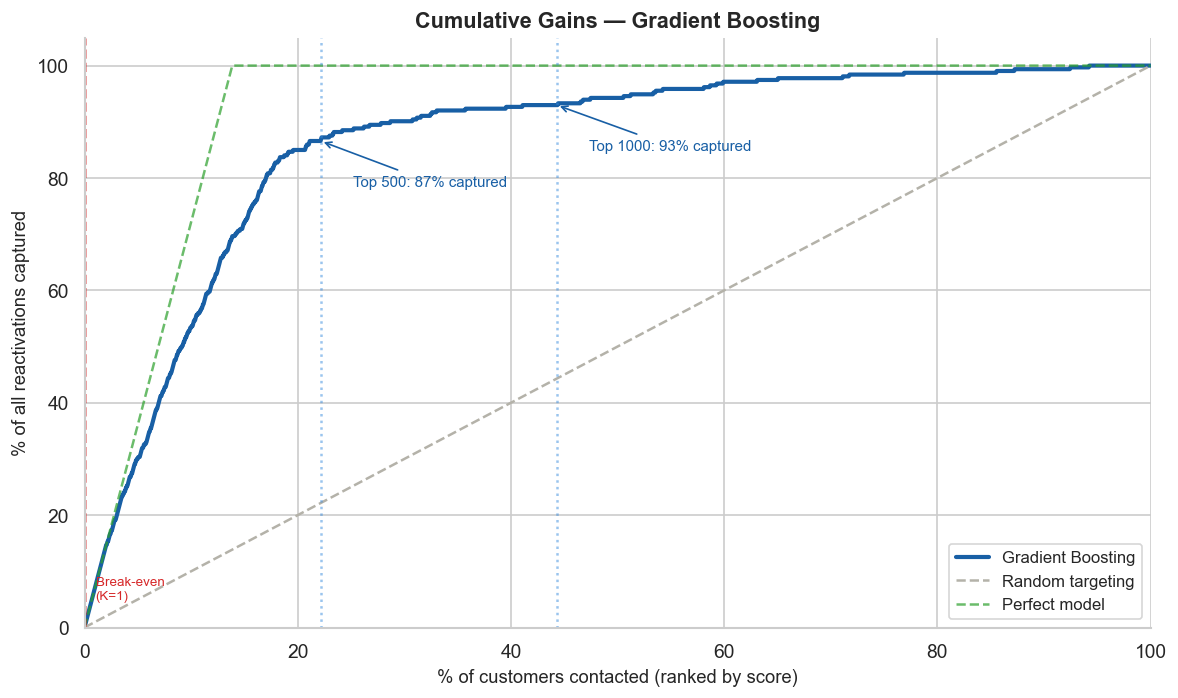

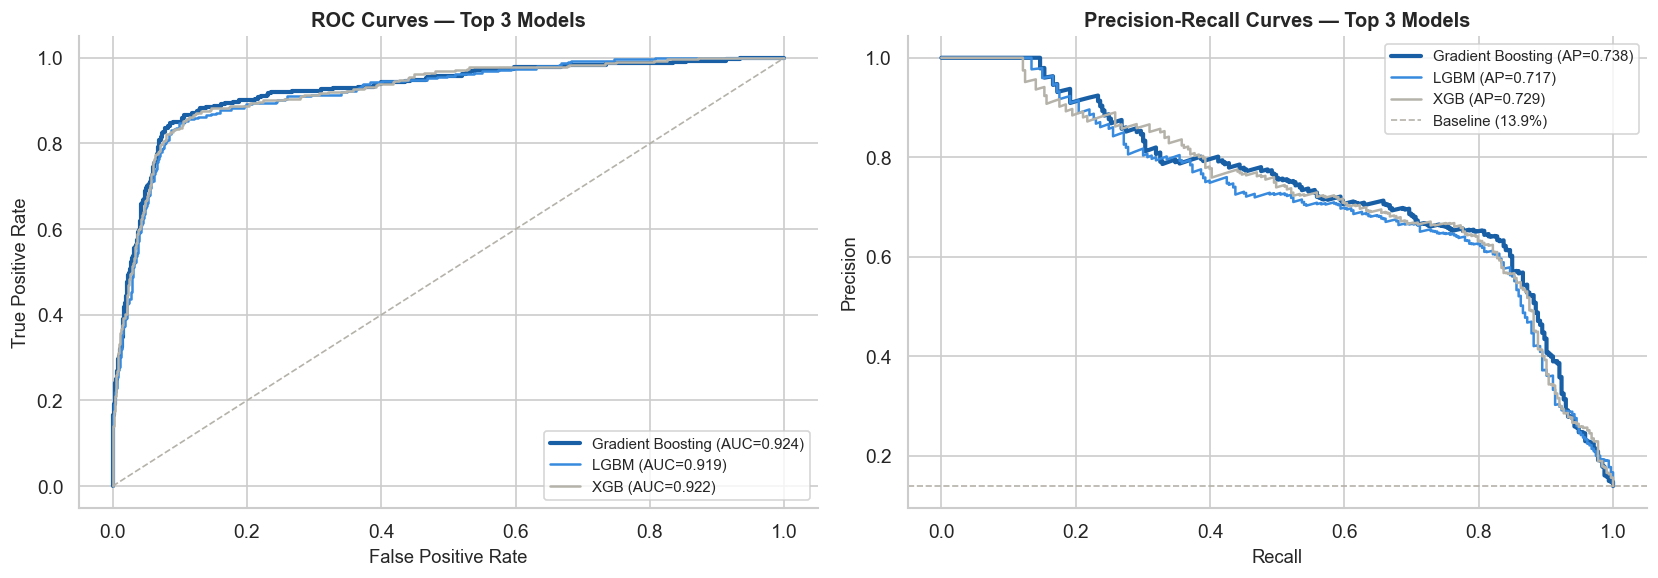

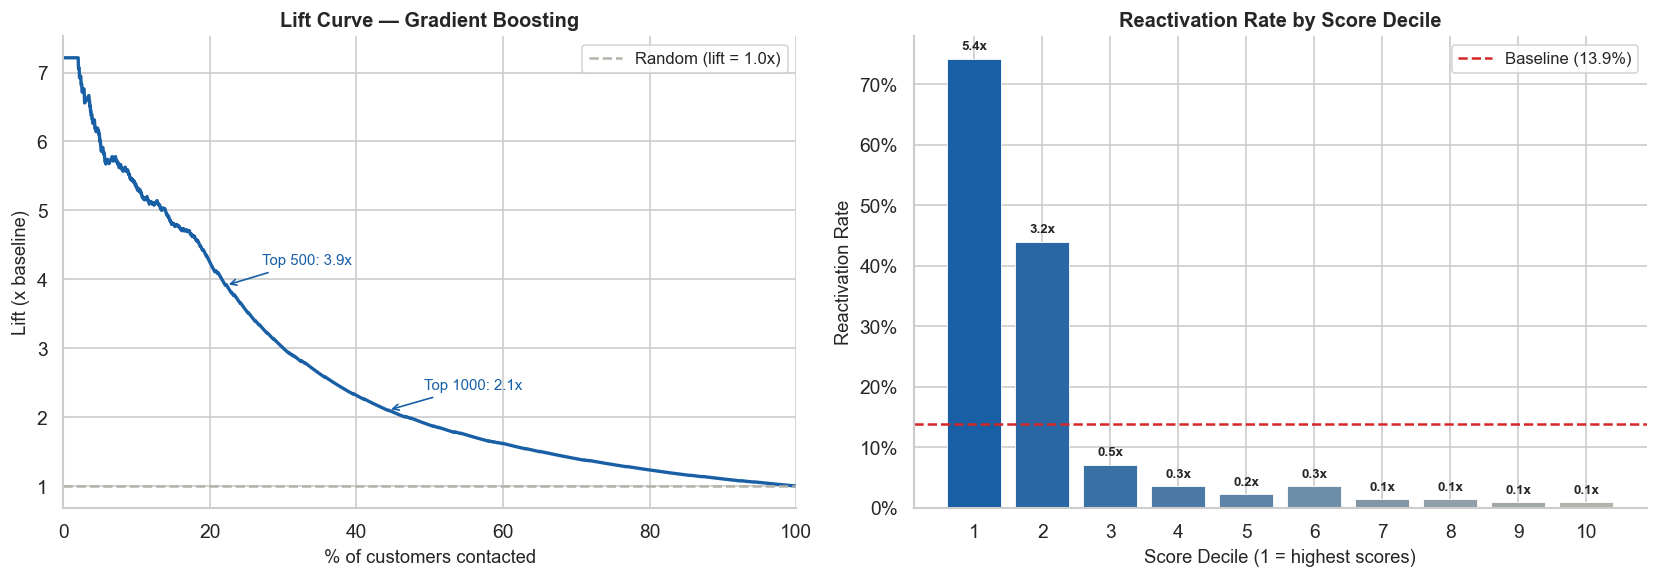

In [14]:
# ══════════════════════════════════════════════════════════════════════════
# EVALUATION METRICS — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════

BLUE_PRIMARY  = '#185FA5'
BLUE_SECONDARY = '#378ADD'
GRAY_MUTED    = '#B4B2A9'
model_colors  = [BLUE_PRIMARY, BLUE_SECONDARY, GRAY_MUTED]

# ── Chart 1: Cumulative Gains Curve ──
fig, ax = plt.subplots(figsize=(10, 6))

pct_contacted = eval_df['k_pct'].values * 100
cum_gain_pct  = eval_df['cum_gain'].values * 100

# Perfect model: captures all positives in the first baseline% of clients
perfect_x = [0, baseline * 100, 100]
perfect_y = [0, 100, 100]

ax.plot(pct_contacted, cum_gain_pct, color=BLUE_PRIMARY, linewidth=2.5,
        label=f'{best_model_name}')
ax.plot([0, 100], [0, 100], '--', color=GRAY_MUTED, linewidth=1.5,
        label='Random targeting')
ax.plot(perfect_x, perfect_y, '--', color='#2CA02C', linewidth=1.5, alpha=0.7,
        label='Perfect model')

# Annotate at K=500 and K=1000 (if within test set)
for k_anno in [500, 1000]:
    if k_anno <= N:
        x_val = k_anno / N * 100
        y_val = eval_df.iloc[k_anno - 1]['cum_gain'] * 100
        ax.axvline(x=x_val, color=BLUE_SECONDARY, linestyle=':', alpha=0.5)
        ax.annotate(f'Top {k_anno}: {y_val:.0f}% captured',
                    xy=(x_val, y_val), xytext=(x_val + 3, y_val - 8),
                    fontsize=9, color=BLUE_PRIMARY,
                    arrowprops=dict(arrowstyle='->', color=BLUE_PRIMARY, lw=1))

# Break-even marker
if breakeven_k is not None:
    be_x = breakeven_k / N * 100
    ax.axvline(x=be_x, color='#D62728', linestyle='--', alpha=0.6)
    ax.text(be_x + 1, 5, f'Break-even\n(K={breakeven_k})', fontsize=8, color='#D62728')

ax.set_xlabel('% of customers contacted (ranked by score)', fontsize=11)
ax.set_ylabel('% of all reactivations captured', fontsize=11)
ax.set_title(f'Cumulative Gains — {best_model_name}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# ── Charts 2 + 3: ROC and PR Curves (top 3 models) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for i, (name, (fpr, tpr, auc_val)) in enumerate(roc_data.items()):
    color = model_colors[i % len(model_colors)]
    lw = 2.5 if i == 0 else 1.5
    ax1.plot(fpr, tpr, color=color, linewidth=lw,
             label=f'{name} (AUC={auc_val:.3f})')
ax1.plot([0, 1], [0, 1], '--', color=GRAY_MUTED, linewidth=1)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves — Top 3 Models', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)

# PR
for i, (name, (prec, rec, ap_val)) in enumerate(pr_data.items()):
    color = model_colors[i % len(model_colors)]
    lw = 2.5 if i == 0 else 1.5
    ax2.plot(rec, prec, color=color, linewidth=lw,
             label=f'{name} (AP={ap_val:.3f})')
ax2.axhline(y=baseline, linestyle='--', color=GRAY_MUTED, linewidth=1,
            label=f'Baseline ({baseline:.1%})')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curves — Top 3 Models', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ── Charts 4 + 5: Lift Curve + Decile Bar Chart ──
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# Lift curve
ax3.plot(pct_contacted, eval_df['lift'].values, color=BLUE_PRIMARY, linewidth=2)
ax3.axhline(y=1.0, linestyle='--', color=GRAY_MUTED, linewidth=1.5,
            label='Random (lift = 1.0x)')

for k_anno in [500, 1000]:
    if k_anno <= N:
        x_val = k_anno / N * 100
        y_val = eval_df.iloc[k_anno - 1]['lift']
        ax3.annotate(f'Top {k_anno}: {y_val:.1f}x',
                     xy=(x_val, y_val), xytext=(x_val + 5, y_val + 0.3),
                     fontsize=9, color=BLUE_PRIMARY,
                     arrowprops=dict(arrowstyle='->', color=BLUE_PRIMARY, lw=1))

ax3.set_xlabel('% of customers contacted', fontsize=11)
ax3.set_ylabel('Lift (x baseline)', fontsize=11)
ax3.set_title(f'Lift Curve — {best_model_name}', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.set_xlim(0, 100)

# Decile bar chart
decile_nums = [d + 1 for d in range(10)]
decile_rates = []
decile_lifts = []
for d in range(10):
    start = d * decile_size
    end = (d + 1) * decile_size if d < 9 else N
    chunk = y_sorted[start:end]
    rate = chunk.sum() / len(chunk)
    decile_rates.append(rate)
    decile_lifts.append(rate / baseline if baseline > 0 else 0)

# Color gradient: dark blue for top deciles, gray for bottom
bar_colors = []
for d in range(10):
    frac = d / 9  # 0 = top decile, 1 = bottom
    r = int(24 + frac * (180 - 24))
    g = int(95 + frac * (178 - 95))
    b = int(165 + frac * (169 - 165))
    bar_colors.append(f'#{r:02x}{g:02x}{b:02x}')

bars = ax4.bar(decile_nums, decile_rates, color=bar_colors, edgecolor='white', linewidth=0.5)
ax4.axhline(y=baseline, linestyle='--', color='#D62728', linewidth=1.5,
            label=f'Baseline ({baseline:.1%})')

# Annotate lift on each bar
for d, (bar, lift_val) in enumerate(zip(bars, decile_lifts)):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{lift_val:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax4.set_xlabel('Score Decile (1 = highest scores)', fontsize=11)
ax4.set_ylabel('Reactivation Rate', fontsize=11)
ax4.set_title('Reactivation Rate by Score Decile', fontsize=12, fontweight='bold')
ax4.set_xticks(decile_nums)
ax4.legend(loc='upper right', fontsize=10)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## SHAP — FEATURE IMPORTANCE & INTERPRETABILITY

**WHAT THIS DOES:**
  Explains WHY the model makes its predictions:

  A) BUILT-IN IMPORTANCE: Which features the tree model splits on most (impurity-based).
     Shows a horizontal bar chart of the top 18 features.

  B) SHAP SUMMARY PLOT: For each feature, shows:
     - How important it is (y-axis position)
     - Whether high/low values push toward reactivation or not (color)
     - The spread of effects (dot distribution)

  C) SHAP FORCE PLOT: Explains a SINGLE client — why did THIS specific person
     get a high or low score? Very useful for sales team briefings.

**WHY IT MATTERS:**
  For a consultancy deliverable, explaining "which features matter and why" is
  just as important as the prediction itself. The client needs to trust the model
  and understand what drives reactivation.

**POTENTIAL ISSUES:**
  ⚠️  The model is RE-FIT on the FULL dataset (model, y) for SHAP analysis.
  This means the SHAP explanations are for a model trained on ALL data (including
  what was validation/test), not the model that was evaluated. The feature importances
  could differ from the validated model.

  ⚠️  Impurity-based feature importance (built-in) is biased toward high-cardinality
  features and continuous variables. SHAP is more reliable.

**ALTERNATIVES:**
  - Use permutation importance instead of impurity-based importance.
  - Use SHAP on the validation-set model (not re-fitted on full data).
  - Add partial dependence plots (PDPs) for the top features.
  - Consider using ELI5 or LIME as simpler alternatives to SHAP.

**RECOMMENDATION:**
  (1) DO NOT refit on full data for SHAP. Use the model that was already trained
      on the training set. The whole point of SHAP is to explain the model you
      actually evaluated — refitting changes the model and breaks that link.
      Just use: fitted_model = best_model.named_steps['model']  (already fitted)

  (2) Drop the impurity-based importance chart or label it clearly as "approximate."
      SHAP is strictly better — it's exact, unbiased, and shows direction. Showing
      both can confuse stakeholders if the rankings differ.

  (3) ADD PARTIAL DEPENDENCE PLOTS for the top 3-4 features. These show the
      relationship between a feature and the prediction (e.g., "as total spend
      increases, reactivation probability increases up to €10K then plateaus").
      PDPs are very intuitive for non-technical audiences and complement SHAP well.
      Code: from sklearn.inspection import PartialDependenceDisplay

  (4) The SHAP force plot for individual clients is excellent — keep it. Consider
      generating force plots for 3-5 representative clients (one from each tier)
      to include in the final presentation.


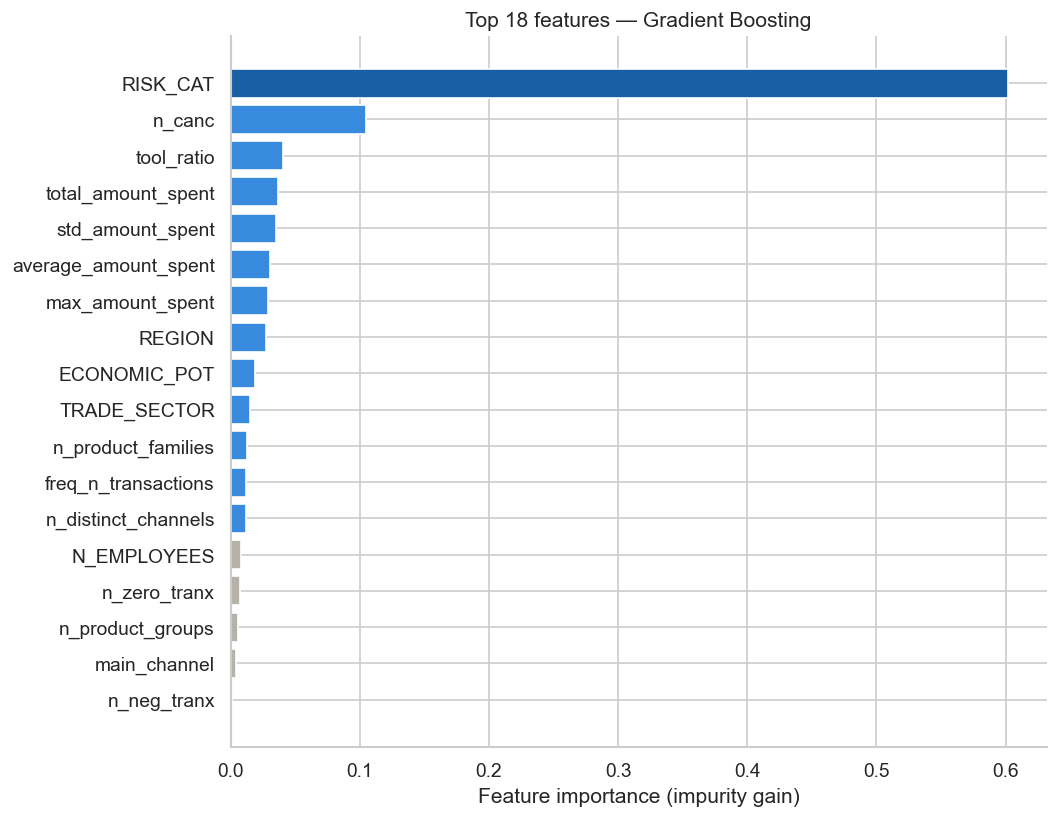


Top 10 features:
RISK_CAT                0.601714
n_canc                  0.104532
tool_ratio              0.040598
total_amount_spent      0.036284
std_amount_spent        0.035267
average_amount_spent    0.030749
max_amount_spent        0.028737
REGION                  0.027530
ECONOMIC_POT            0.019111
TRADE_SECTOR            0.014642
Install SHAP to run this cell: pip install shap


In [15]:
feature_names_out = NUMERIC_FEATURES + CATEGORICAL_FEATURES

best_pipeline = fitted_models[best_model_name]
fitted_model = best_pipeline.named_steps['model']

if hasattr(fitted_model, 'feature_importances_'):
    importances = pd.Series(
        fitted_model.feature_importances_,
        index=feature_names_out
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 7))
    top_n = importances.head(18)
    colors = ['#185FA5' if i == 0 else ('#378ADD' if v > 0.01 else '#B4B2A9')
              for i, v in enumerate(top_n)]
    ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1])
    ax.set_xlabel('Feature importance (impurity gain)')
    ax.set_title(f'Top 18 features — {best_model_name}')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 features:')
    print(importances.head(10).to_string())

# SHAP summary plot
if SHAP_AVAILABLE:
    import sklearn

    prep_fitted = best_pipeline.named_steps['prep']
    X_transformed = prep_fitted.transform(model)

    # Sample 1,000 clients for speed (representative subset)
    sample_size = min(1000, X_transformed.shape[0])
    np.random.seed(42)
    sample_indices = np.random.choice(X_transformed.shape[0], sample_size, replace=False)
    X_transformed_sample = X_transformed[sample_indices]

    # Dynamic explainer: LinearExplainer for LogReg, TreeExplainer for tree models
    if isinstance(fitted_model, sklearn.linear_model.LogisticRegression):
        explainer = shap.LinearExplainer(fitted_model, X_transformed_sample)
    else:
        explainer = shap.TreeExplainer(fitted_model)

    shap_values = explainer.shap_values(X_transformed_sample)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap.summary_plot(
        shap_values, X_transformed_sample,
        feature_names=feature_names_out,
        show=True, plot_size=(10, 7)
    )
else:
    print('Install SHAP to run this cell: pip install shap')

# SHAP individual explanation
if SHAP_AVAILABLE:
    import sklearn

    prep_fitted = best_pipeline.named_steps['prep']
    X_transformed = prep_fitted.transform(model)

    top_client_idx = best_probs.argmax()

    # Reshape to 2D for the explainer (1, N_features)
    single_client_features_2d = X_transformed[top_client_idx].reshape(1, -1)

    # Dynamic explainer selection
    if isinstance(fitted_model, sklearn.linear_model.LogisticRegression):
        explainer = shap.LinearExplainer(fitted_model, X_transformed)
    else:
        explainer = shap.TreeExplainer(fitted_model)

    single_shap_values = explainer.shap_values(single_client_features_2d)

    # Extract base value safely
    raw_base = explainer.expected_value
    if isinstance(raw_base, (list, np.ndarray)):
        base_val = float(raw_base[1]) if len(raw_base) > 1 else float(raw_base[0])
    else:
        base_val = float(raw_base)

    # Extract SHAP values and flatten safely
    if isinstance(single_shap_values, list):
        single_shap_1d = single_shap_values[1][0]
    else:
        if len(single_shap_values.shape) == 3:
            single_shap_1d = single_shap_values[0, :, 1]
        else:
            single_shap_1d = single_shap_values[0]

    single_features_1d = single_client_features_2d[0]

    print(f'Client index: {top_client_idx}  |  Score: {best_probs[top_client_idx]:.3f}  |  Actual target: {y.iloc[top_client_idx]}')

    shap.force_plot(
        base_val,
        single_shap_1d,
        single_features_1d,
        feature_names=feature_names_out,
        matplotlib=True
    )
    plt.show()


## COVID-CHURNED vs. NORMALLY-CHURNED — GROUP COMPARISON

**WHAT THIS DOES:**
  Compares clients whose churn was likely driven by COVID (sector experienced >30% transaction drop)
  against clients who churned under normal market conditions. The goal is to determine whether
  these two groups should be targeted with different campaign strategies.

**KEY QUESTIONS:**
  1. Do COVID-churned clients reactivate at a higher rate? (Are they lower-hanging fruit?)
  2. Do they have different profiles — size, economic potential, sector mix?
  3. Did they behave differently before churning — spending, frequency, channel use?
  4. Does the model score them differently? (Should we run separate campaigns?)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# COVID-CHURNED vs. NORMALLY-CHURNED — GROUP COMPARISON
# ══════════════════════════════════════════════════════════════════════════

# Split clients into two groups based on the covid_sensitive flag
covid_mask = model['covid_sensitive'] == 1
n_covid = covid_mask.sum()
n_normal = (~covid_mask).sum()

print(f'COVID-churned clients:    {n_covid:>6,}  ({n_covid/len(model)*100:.1f}%)')
print(f'Normally-churned clients: {n_normal:>6,}  ({n_normal/len(model)*100:.1f}%)')
print()

# ── 1. REACTIVATION RATES ─────────────────────────────────────────────────
react_covid  = y[covid_mask].mean()
react_normal = y[~covid_mask].mean()
react_overall = y.mean()

print('=== REACTIVATION RATES ===')
print(f'  COVID-churned:    {react_covid:.1%}')
print(f'  Normally-churned: {react_normal:.1%}')
print(f'  Overall:          {react_overall:.1%}')
print(f'  Difference:       {react_covid - react_normal:+.1%} pp')
print()

# ── 2. CLIENT PROFILE COMPARISON ──────────────────────────────────────────
profile_features = [
    'N_EMPLOYEES', 'ECONOMIC_POT', 'total_amount_spent',
    'freq_n_transactions', 'tenure_months'
]
profile_rows = []
for feat in profile_features:
    if feat in model.columns:
        profile_rows.append({
            'Feature': feat,
            'COVID-churned (median)': model.loc[covid_mask, feat].median(),
            'Normal-churned (median)': model.loc[~covid_mask, feat].median(),
            'Ratio (COVID/Normal)': round(
                model.loc[covid_mask, feat].median() /
                max(model.loc[~covid_mask, feat].median(), 0.001), 2
            )
        })

print('=== CLIENT PROFILE (medians) ===')
print(pd.DataFrame(profile_rows).to_string(index=False))
print()

# ── 3. BEHAVIORAL DIFFERENCES ────────────────────────────────────────────
behavior_features = [
    'average_amount_spent', 'n_distinct_channels', 'n_product_families',
    'tool_ratio', 'months_since_last_purchase', 'avg_purchase_gap',
    'spending_trend', 'cancellation_rate', 'avg_basket_size',
    'family_concentration', 'item_concentration'
]
behavior_rows = []
for feat in behavior_features:
    if feat in model.columns:
        med_c = model.loc[covid_mask, feat].median()
        med_n = model.loc[~covid_mask, feat].median()
        behavior_rows.append({
            'Feature': feat,
            'COVID-churned': round(med_c, 3),
            'Normal-churned': round(med_n, 3),
            'Diff %': round((med_c - med_n) / max(abs(med_n), 0.001) * 100, 1)
        })

print('=== BEHAVIORAL DIFFERENCES (medians) ===')
print(pd.DataFrame(behavior_rows).to_string(index=False))
print()

# ── 4. CATEGORICAL PROFILE ───────────────────────────────────────────────
print('=== TOP SECTORS BY GROUP ===')
# Reconstruct trade sector from clients_churn
_sectors = clients_churn.set_index('CLIENT_ID')['TRADE SECTOR']
_model_ids = clients_churn.sort_values('CLIENT_ID', ascending=True)['CLIENT_ID'].values
_sector_series = pd.Series(_sectors.loc[_model_ids].values, index=model.index)

print('\nCOVID-churned — top 5 sectors:')
print(_sector_series[covid_mask].value_counts().head().to_string())
print('\nNormally-churned — top 5 sectors:')
print(_sector_series[~covid_mask].value_counts().head().to_string())
print()

# ── 5. MODEL SCORE DISTRIBUTION ──────────────────────────────────────────
scores_covid  = best_probs[covid_mask]
scores_normal = best_probs[~covid_mask]

print('=== MODEL SCORE DISTRIBUTION ===')
print(f'  COVID-churned:    mean={scores_covid.mean():.3f}  median={np.median(scores_covid):.3f}  std={scores_covid.std():.3f}')
print(f'  Normal-churned:   mean={scores_normal.mean():.3f}  median={np.median(scores_normal):.3f}  std={scores_normal.std():.3f}')
print()

# Score distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(scores_normal, bins=40, alpha=0.6, color='#185FA5', label=f'Normal (n={n_normal:,})', density=True)
axes[0].hist(scores_covid, bins=40, alpha=0.6, color='#D62728', label=f'COVID (n={n_covid:,})', density=True)
axes[0].set_xlabel('Reactivation Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Churn Type')
axes[0].legend()

# Reactivation rate by score decile, split by group
decile_rows = []
for group_name, mask in [('COVID-churned', covid_mask), ('Normal-churned', ~covid_mask)]:
    g_scores = best_probs[mask]
    g_target = y[mask]
    deciles = pd.qcut(g_scores, 5, labels=['Bottom','Low','Mid','High','Top'], duplicates='drop')
    for d in deciles.unique():
        d_mask = deciles == d
        decile_rows.append({
            'Group': group_name,
            'Score tier': str(d),
            'n': int(d_mask.sum()),
            'React. rate': round(float(g_target[d_mask].mean()), 3),
            'Avg score': round(float(g_scores[d_mask].mean()), 3)
        })

decile_df = pd.DataFrame(decile_rows)
print('=== REACTIVATION BY SCORE TIER & GROUP ===')
print(decile_df.to_string(index=False))
print()

# Bar chart
tier_order = ['Bottom','Low','Mid','High','Top']
covid_rates = decile_df[decile_df['Group']=='COVID-churned'].set_index('Score tier').reindex(tier_order)['React. rate']
normal_rates = decile_df[decile_df['Group']=='Normal-churned'].set_index('Score tier').reindex(tier_order)['React. rate']
x = np.arange(len(tier_order))
w = 0.35
axes[1].bar(x - w/2, normal_rates, w, color='#185FA5', label='Normal-churned')
axes[1].bar(x + w/2, covid_rates, w, color='#D62728', label='COVID-churned')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_order)
axes[1].set_ylabel('Reactivation Rate')
axes[1].set_title('Reactivation Rate by Score Tier & Churn Type')
axes[1].legend()
plt.tight_layout()
plt.show()

# ── 6. STRATEGIC SUMMARY ─────────────────────────────────────────────────
print('=== STRATEGIC SUMMARY ===')
print(f'  COVID-churned clients represent {n_covid/len(model)*100:.1f}% of the churned base.')
if react_covid > react_normal:
    print(f'  They reactivate at {react_covid/react_normal:.1f}x the rate of normally-churned clients.')
    print(f'  → These are LOWER-HANGING FRUIT: they likely stopped buying due to external')
    print(f'    constraints, not dissatisfaction. A lighter-touch campaign may suffice.')
else:
    print(f'  They reactivate at {react_covid/react_normal:.1f}x the rate of normally-churned clients.')
    print(f'  → COVID compounded genuine disengagement. These clients may need stronger')
    print(f'    incentives to return.')
print()
if abs(scores_covid.mean() - scores_normal.mean()) > 0.05:
    print(f'  The model scores them differently (delta={scores_covid.mean()-scores_normal.mean():+.3f}),')
    print(f'  suggesting different campaign strategies are warranted.')
else:
    print(f'  The model scores them similarly (delta={scores_covid.mean()-scores_normal.mean():+.3f}),')
    print(f'  suggesting a unified campaign may work, but messaging could differ.')


## SCORING & CAMPAIGN PRIORITISATION

**WHAT THIS DOES:**
  Assigns every churned client a reactivation score and sorts them into tiers:

  | Tier      | Score     | Action                                         |
  |-----------|-----------|------------------------------------------------|
  | Very High | > 0.80    | Direct outreach, personal calls, premium offer |
  | High      | 0.60-0.80 | Email + phone, targeted discount               |
  | Medium    | 0.30-0.60 | Mass email campaign                            |
  | Low       | < 0.30    | Do not contact (ROI likely negative)           |

  Also calculates business value: total economic potential per tier.

**WHY IT MATTERS:**
  THIS IS THE DELIVERABLE. The client doesn't care about AUC — they care about
  "which customers should we call first?" This section turns model output into
  an actionable campaign plan.

**POTENTIAL ISSUES:**
  ⚠️  The tier thresholds (0.30, 0.60, 0.80) are arbitrary. They should be
  tuned based on the actual cost of outreach vs expected revenue per reactivated
  client. A formal cost-benefit analysis would determine optimal cutoffs.

  ⚠️  scores_df uses final_clients_churn.index as CLIENT_ID, not the actual
  CLIENT_ID column. If the index was reset at any point, this could map wrong IDs.

  ⚠️  The scores are from best_probs which (per the code) comes from the validation
  set evaluation. But for campaign scoring, you'd want to score ALL churned clients,
  not just the validation subset. The SHAP section re-fits on full data, but the
  scoring section seems to use the earlier probabilities.

**ALTERNATIVES:**
  - Use a cost-sensitive threshold optimization (maximize expected profit).
  - Add a "confidence" column — clients near tier boundaries could be flagged for
    human review.
  - Include the top SHAP features for each client so the sales team knows WHY
    a client is ranked high (e.g., "high economic potential + recent activity").

**RECOMMENDATION:**
  (1) SCORE ALL CHURNED CLIENTS using the final model, not just a subset. Train
      the model on all data (after validation confirms it works), then predict on
      the full churned population. Right now there's ambiguity about which clients
      are actually being scored.

  (2) REPLACE ARBITRARY THRESHOLDS with data-driven ones. Use the decile lift table:
      if the top 3 deciles (30%) have lift > 1.5x, make that "Very High + High."
      Or better: ask the client "how many clients can you realistically contact?"
      and set the threshold to match that capacity.

  (3) ADD TOP-3 SHAP REASONS per client. This is the single biggest value-add
      for the sales team. Instead of just "score = 0.85", they see:
      "score = 0.85 — driven by: high economic potential (+0.15), recent purchase
      history (+0.12), multi-channel buyer (+0.08)."
      This makes the model actionable at the individual level.

  (4) Fix the CLIENT_ID mapping — use .values from the actual CLIENT_ID column,
      not the dataframe index. This is a correctness issue.


In [16]:
final_clients_churn = clients_churn[['CLIENT_ID']].copy()

scores_df = pd.DataFrame({
    'CLIENT_ID'          : final_clients_churn['CLIENT_ID'].values,
    'reactivation_score' : best_probs,
    'target'             : y.values
})

scores_df = scores_df.merge(
    clients[['CLIENT_ID','RISK_CAT','ECO_POT_CLASS','ECONOMIC_POT','REGION','TRADE SECTOR']],
    on='CLIENT_ID', how='left'
)

scores_df['priority_tier'] = pd.cut(
    scores_df['reactivation_score'],
    bins=[0, 0.30, 0.60, 0.80, 1.001],
    labels=['Low', 'Medium', 'High', 'Very High']
)

scores_df = scores_df.sort_values('reactivation_score', ascending=False).reset_index(drop=True)

print('Score distribution:')
print(scores_df['reactivation_score'].describe())

# --- Tier summary ---
baseline_rate = y.mean()

tier_summary = (
    scores_df.groupby('priority_tier', observed=False)
    .agg(
        n_clients       = ('CLIENT_ID',           'count'),
        reactivation_rate = ('target',             'mean'),
        avg_score       = ('reactivation_score',   'mean'),
        total_eco_pot   = ('ECONOMIC_POT',         'sum')
    )
    .sort_values('avg_score', ascending=False)
)

tier_summary['reactivation_vs_baseline'] = tier_summary['reactivation_rate'] / baseline_rate
tier_summary['pct_of_churned_base']       = tier_summary['n_clients'] / len(scores_df)

print('Campaign tier summary:')
print(tier_summary)


Score distribution:
count    15049.000000
mean         0.134573
std          0.255394
min          0.001302
25%          0.010680
50%          0.021181
75%          0.053232
max          0.997832
Name: reactivation_score, dtype: float64
Campaign tier summary:
               n_clients  reactivation_rate  avg_score  total_eco_pot  \
priority_tier                                                           
Very High            736           0.976902   0.906682     3492124.00   
High                 860           0.851163   0.704191     4043728.56   
Medium               865           0.367630   0.456165     4316548.22   
Low                12588           0.021370   0.028415    62464597.94   

               reactivation_vs_baseline  pct_of_churned_base  
priority_tier                                                 
Very High                      7.213641             0.048907  
High                           6.285156             0.057147  
Medium                         2.714654          

## EXPORT

**WHAT THIS DOES:**
  Saves the final scored client list as a CSV file that can be handed to the
  marketing/sales team. Each row is one churned client with their:
  - Reactivation score (0-1 probability)
  - Priority tier (Very High / High / Medium / Low)
  - Key attributes (risk category, economic potential, region, sector)

**POTENTIAL ISSUES:**
  - The 'target' column (actual outcome) is included in scores_df but excluded
    from the export — good, since in a real deployment you wouldn't have the target.
  - Output column references 'TRADE_SECTOR' but the merge used 'TRADE SECTOR'
    (with a space). This would crash.

**ALTERNATIVES:**
  - Export to Excel with formatting and conditional coloring per tier.
  - Include top 3 SHAP features per client for actionable insights.
  - Add a "recommended action" column based on tier + economic potential.
  - Push directly to a CRM system via API instead of CSV.

**RECOMMENDATION:**
  (1) Fix the column name mismatch ('TRADE SECTOR' vs 'TRADE_SECTOR').
  (2) Export as BOTH CSV and formatted Excel. The CSV is for data pipelines / CRM
      import. The Excel is for the human stakeholders — add conditional formatting
      (green for Very High, red for Low), freeze the header row, and auto-size columns.
      pandas has .to_excel() with xlsxwriter engine for formatting.
  (3) Add a "recommended_action" column that maps tiers to specific actions
      (e.g., "Personal call + premium offer" for Very High). This makes the file
      self-documenting — anyone can open it and know what to do without reading
      the methodology.
  (4) Include top-3 SHAP reasons per client (as mentioned in Section 14).
      This turns the export from a "score list" into a "sales brief."


In [17]:
output_cols = [
    'CLIENT_ID', 'reactivation_score', 'priority_tier',
    'RISK_CAT', 'ECO_POT_CLASS', 'ECONOMIC_POT', 'REGION', 'TRADE SECTOR'
]

output_df = scores_df[output_cols].copy()
output_df.to_csv('reactivation_scored_clients.csv', index=False)

print(f'Exported {len(output_df):,} scored clients to reactivation_scored_clients.csv')
print(f'\nTop 20 clients for the campaign:')
print(output_df.head(20))


# ======================================================================================
# SUMMARY OF ALL ISSUES FOUND
# ======================================================================================
#
# BUGS:
#   1. tool_ratio listed TWICE in NUMERIC_FEATURES (Section 10)
#   2. str.zfill(0) does nothing — should be zfill(6) or use .dt accessor (Section 6)
#   3. n_canc uses .count() instead of .sum() — counts all rows, not cancellations (Section 9)
#   4. Evaluation code references 'probs'/'auc' but training stores 'probs_valid'/'auc_valid' (Section 12)
#   5. Percentage in to_display1 divides by sales count, not client count (Section 7)
#   6. Export references 'TRADE SECTOR' but the column is 'TRADE SECTOR' with a space (Section 15)
#   7. "Bababababa" placeholder text in model selection rationale table (Section 11)
#
# MISSING FEATURES (HIGH IMPACT):
#   8. Recency — months since last purchase (typically the #1 predictor)
#   9. Tenure — how long the client has been a customer
#   10. Spending trend — is spending going up or down?
#   11. Inter-purchase gap — average time between purchases
#
# METHODOLOGICAL CONCERNS:
#   12. shuffle=False in train_test_split — data sorted by CLIENT_ID, not time
#   13. Class imbalance handling inconsistent across models
#   14. No hyperparameter tuning performed
#   15. SHAP model re-fitted on full data (different from validated model)
#   16. Methodology description says cross-validation, code does train/valid/test split
#   17. ~50% baseline rate suggests churn definition may be too lenient
#   18. COVID-19 impact on 2020-2021 target window not addressed
#   19. No model calibration (predicted probabilities may not be well-calibrated)
#   20. OrdinalEncoder used for Logistic Regression (should be OneHotEncoder)
#
# ======================================================================================


Exported 15,049 scored clients to reactivation_scored_clients.csv

Top 20 clients for the campaign:
   CLIENT_ID  reactivation_score priority_tier RISK_CAT ECO_POT_CLASS  \
0   00078216            0.997832     Very High       5a             E   
1   00074877            0.997708     Very High       5a             D   
2   00035157            0.997600     Very High       5a             E   
3   00045753            0.997363     Very High       5a             E   
4   00040641            0.997327     Very High       5a             E   
5   00078683            0.997157     Very High       5a             E   
6   00014213            0.997141     Very High       5a             D   
7   00072955            0.997122     Very High       5a             E   
8   00028755            0.996868     Very High       5a             E   
9   00075361            0.996753     Very High       5a             E   
10  00073341            0.996721     Very High       5a             E   
11  00079179            

## SUMMARY OF ALL ISSUES FOUND

BUGS:
  1. tool_ratio listed TWICE in NUMERIC_FEATURES (Section 10)
  2. str.zfill(0) does nothing — should be zfill(6) or use .dt accessor (Section 6)
  3. n_canc uses .count() instead of .sum() — counts all rows, not cancellations (Section 9)
  4. Evaluation code references 'probs'/'auc' but training stores 'probs_valid'/'auc_valid' (Section 12)
  5. Percentage in to_display1 divides by sales count, not client count (Section 7)
  6. Export references 'TRADE_SECTOR' but the column is 'TRADE SECTOR' with a space (Section 15)
  7. "Bababababa" placeholder text in model selection rationale table (Section 11)

MISSING FEATURES (HIGH IMPACT):
  8. Recency — months since last purchase (typically the #1 predictor)
  9. Tenure — how long the client has been a customer
  10. Spending trend — is spending going up or down?
  11. Inter-purchase gap — average time between purchases

METHODOLOGICAL CONCERNS:
  12. shuffle=False in train_test_split — data sorted by CLIENT_ID, not time
  13. Class imbalance handling inconsistent across models
  14. No hyperparameter tuning performed
  15. SHAP model re-fitted on full data (different from validated model)
  16. Methodology description says cross-validation, code does train/valid/test split
  17. ~50% baseline rate suggests churn definition may be too lenient
  18. COVID-19 impact on 2020-2021 target window not addressed
  19. No model calibration (predicted probabilities may not be well-calibrated)
  20. OrdinalEncoder used for Logistic Regression (should be OneHotEncoder)
